# **ASM Customer Models — Group 2.7 - Customer Models 2025–2026**
## NYC Yellow Cab: Getting Your Fare Share


## Table of Contents

1. **Setup** — packages, data ingestion, weather join, column selection
2. **Data Quality Checks** — missing data, outliers, domain validation
3. **Data Cleaning & Feature Engineering** — filtering, encoding, derived features
4. **Challenge Subsets & Multicollinearity** — C1/C2/C3 samples + VIF check
5. **Challenge 1** — What drives tipping?
6. **Challenge 2** — The Morning Launch
7. **Challenge 3** — The Turnover Trap


## PART 1. SETUP   

Loads (i) the 100k-trip NYC yellow-cab February-2026 sample, (ii) NTA-level demographics and socio-economic indicators, (iii) hourly weather from Open-Meteo (Central Park station), and (iv) TLC licence records.

### 1.1 Import Packages

In [ ]:
# ----------------------------------------------------------------
# 1.1 Import Packages
# ----------------------------------------------------------------

!pip install pandas numpy fastparquet requests lifelines scikit-learn

import pandas as pd
import numpy as np
import requests
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
from lifelines.statistics import proportional_hazard_test
from scipy import stats as sps, optimize

warnings.filterwarnings('ignore')

### 1.2 Load Main Taxi + Demographic Data

In [ ]:
# GitHub URL for the raw data
gh_url = "https://raw.githubusercontent.com/rphars/taxidata/main/"

# ----------------------------------------------------------------
# 1.2 Load Main Taxi Data
# ----------------------------------------------------------------

taxi_data = pd.read_parquet(f"{gh_url}taxi_data_100k.parquet", engine='fastparquet')

# ----------------------------------------------------------------
# 1.3 Load & Join Demographic Data
# ----------------------------------------------------------------

demdata = pd.read_csv(f"{gh_url}demdata_simpl.csv", sep=";", low_memory=False)
socdata = pd.read_csv(f"{gh_url}socdata_simpl.csv", sep=";", low_memory=False)
housingdata = pd.read_csv(f"{gh_url}housingdata_simpl.csv", sep=";", low_memory=False)
econdata = pd.read_csv(f"{gh_url}econdata_simpl.csv", sep=";", low_memory=False)

# The standard comma-separated company data file
company_data = pd.read_csv(f"{gh_url}Issued_Licenses_20260401.csv", low_memory=False)

# =====================================================
# 3. JOIN DEMOGRAPHIC DATA (Pickup & Dropoff)
# =====================================================

# Filter demographic columns to only select those you want to merge. You can add columns and -of course- the other datasets here.
demdata_subset = demdata[['GeoID', 'Pop_1E']].copy()

#a. Join for Pickup (PU)
# Create a dictionary to rename all columns (except GeoID) with a "PU_" prefix
pu_rename = {col: f"PU_{col}" for col in demdata_subset.columns if col != 'GeoID'}
demdata_pu = demdata_subset.rename(columns=pu_rename)

# Perform the left join and drop the redundant RHS key
taxi_data = pd.merge(
    taxi_data,
    demdata_pu,
    how="left",
    left_on="PU_NTA_Code",
    right_on="GeoID"
).drop(columns=['GeoID'])

#b. Join for Dropoff (DO)
# Create a dictionary to rename all columns (except GeoID) with a "DO_" prefix
do_rename = {col: f"DO_{col}" for col in demdata_subset.columns if col != 'GeoID'}
demdata_do = demdata_subset.rename(columns=do_rename)

# Perform the left join and drop the redundant RHS key
taxi_data = pd.merge(
    taxi_data,
    demdata_do,
    how="left",
    left_on="DO_NTA_Code",
    right_on="GeoID"
).drop(columns=['GeoID'])

print(f"✅ Demographic join completed. New shape: {taxi_data.shape[0]:,} × {taxi_data.shape[1]}\n")

✅ Demographic join completed. New shape: 100,000 × 34



### 1.3 Load & Join Weather

In [ ]:
# ----------------------------------------------------------------
# Load Weather Data
# ----------------------------------------------------------------

api_url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=40.7831&longitude=-73.9712&"
    "start_date=2026-02-01&end_date=2026-02-28&"
    "hourly=temperature_2m,relative_humidity_2m,apparent_temperature,"
    "precipitation,snowfall,snow_depth,pressure_msl,cloud_cover,"
    "wind_speed_10m,sunshine_duration,is_day&"
    "timezone=America%2FNew_York"
)

weather_raw = requests.get(api_url).json()
weather_clean = pd.DataFrame(weather_raw['hourly'])

weather_clean = weather_clean.assign(
    datetime = pd.to_datetime(weather_clean['time']).dt.tz_localize("America/New_York"),
    sunshine_minutes = weather_clean['sunshine_duration'] / 60
).drop(columns=['time', 'sunshine_duration'])

print(f"✅ Weather data loaded: {weather_clean.shape[0]} hours\n")

# ----------------------------------------------------------------
# Join Weather to Taxi Data
# ----------------------------------------------------------------

# Convert pickup time to datetime AND make it timezone-aware
taxi_data['pickup_datetime'] = pd.to_datetime(
    taxi_data['tpep_pickup_datetime'],
    errors='coerce'
).dt.tz_localize("America/New_York", ambiguous='NaT', nonexistent='NaT')

# Create hourly key (now has the same timezone as weather)
taxi_data['pickup_date_hour'] = taxi_data['pickup_datetime'].dt.floor('h')

print(f"✅ Datetime prepared with timezone. Example: {taxi_data['pickup_date_hour'].iloc[0]}")
print("\n")

# Join weather data
print("Joining weather data...")

taxi_data = taxi_data.merge(
    weather_clean,
    left_on='pickup_date_hour',
    right_on='datetime',
    how='left'
)

# Remove duplicate datetime column
if 'datetime' in taxi_data.columns:
    taxi_data = taxi_data.drop(columns=['datetime'])

print("✅ Weather data joined successfully!")
print(f"Final shape after weather join: {taxi_data.shape[0]:,} rows × {taxi_data.shape[1]} columns\n")

✅ Weather data loaded: 672 hours

✅ Datetime prepared with timezone. Example: 2026-02-04 14:00:00-05:00


Joining weather data...
✅ Weather data joined successfully!
Final shape after weather join: 100,000 rows × 47 columns



### 1.4 Select Columns

In [ ]:
# ----------------------------------------------------------------
# Select Columns
# ----------------------------------------------------------------

keep_columns = [
    # === Core Trip Information ===
    'pickup_datetime',
    'tpep_dropoff_datetime',
    'tpep_pickup_datetime',
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'payment_type',
    'passenger_count',
    'RatecodeID',

    # === Location ===
    'PULocationID', 'DOLocationID',
    'PU_Borough', 'DO_Borough',
    'PU_Zone', 'DO_Zone',
    'PU_NTA_Code', 'DO_NTA_Code',

    # === Demographics ===
    'PU_Pop_1E', 'DO_Pop_1E',

    # === Time & Derived ===
    'pickup_hour',

    # === Surcharges ===
    'Airport_fee',
    'congestion_surcharge',
    'tolls_amount',

    # === External / Waiting Time ===
    'est_empty_time',
    'event_status',

    # === Weather ===
    'temperature_2m',
    'precipitation',
    'snowfall',
    'wind_speed_10m',
    'apparent_temperature',
    'sunshine_minutes'
]

# Create final dataset
taxi_final = taxi_data[keep_columns].copy()

print(f"Final dataset shape: {taxi_final.shape[0]:,} rows × {taxi_final.shape[1]} columns\n")

# List all columns with their data types
print("=== COLUMN NAMES AND DATA TYPES ===")
print(taxi_final.dtypes)
print("\n")

Final dataset shape: 100,000 rows × 32 columns

=== COLUMN NAMES AND DATA TYPES ===
pickup_datetime          datetime64[us, America/New_York]
tpep_dropoff_datetime                      datetime64[us]
tpep_pickup_datetime                       datetime64[us]
trip_distance                                     float64
fare_amount                                       float64
tip_amount                                        float64
total_amount                                      float64
payment_type                                        int32
passenger_count                                   float64
RatecodeID                                        float64
PULocationID                                        int32
DOLocationID                                        int32
PU_Borough                                         object
DO_Borough                                         object
PU_Zone                                            object
DO_Zone                                       

## PART 2. DATA QUALITY CHECKS   

Three layers of diagnostics before any modelling:

1. **Missing data** — informs imputation/filtering decisions
2. **Outlier detection** — IQR-based flags; combined with p99 capping
3. **Domain checks** — physical/logical constraints (negative fares, cash-tip artifacts, payment-type consistency)


### 2.1 Missing Data

In [ ]:
# ----------------------------------------------------------------
# Missing Data Analysis
# ----------------------------------------------------------------

print("\n=== MISSING DATA ANALYSIS ===")
missing = taxi_final.isnull().mean() * 100
print(missing[missing > 0].sort_values(ascending=False).round(3))


=== MISSING DATA ANALYSIS ===
passenger_count         30.261
RatecodeID              30.261
Airport_fee             30.261
congestion_surcharge    30.261
DO_Pop_1E                0.707
DO_NTA_Code              0.707
PU_NTA_Code              0.176
PU_Pop_1E                0.176
dtype: float64


### 2.2 Outliers (IQR)

In [ ]:
# ----------------------------------------------------------------
# Outlier Analysis (IQR Method)
# ----------------------------------------------------------------

print("=== OUTLIER ANALYSIS ===\n")

numeric_cols = [
    'fare_amount', 'tip_amount', 'trip_distance',
    'total_amount', 'passenger_count', 'est_empty_time'
]

# Descriptive stats first
print("--- Descriptive Statistics ---")
print(taxi_final[numeric_cols].describe().round(2).to_string())
print()

# Flag outliers using IQR method
print("--- Outlier Detection (IQR method) ---")
for col in numeric_cols:
    Q1 = taxi_final[col].quantile(0.25)
    Q3 = taxi_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((taxi_final[col] < lower) | (taxi_final[col] > upper)).sum()
    pct = n_outliers / len(taxi_final) * 100
    print(f"  {col:25s} | lower={lower:.2f}, upper={upper:.2f} | outliers={n_outliers:,} ({pct:.1f}%)")

print()

=== OUTLIER ANALYSIS ===

--- Descriptive Statistics ---
       fare_amount  tip_amount  trip_distance  total_amount  passenger_count  est_empty_time
count    100000.00   100000.00      100000.00     100000.00         69739.00       100000.00
mean         21.62        2.65           6.14         30.10             1.23            6.69
std          18.28        4.09         539.21         21.88             0.64            6.15
min        -250.00       -0.90           0.00       -252.75             0.00            1.00
25%          10.00        0.00           0.99         17.56             1.00            2.00
50%          16.30        2.00           1.80         24.00             1.00            5.00
75%          27.50        3.80           3.69         35.53             1.00           10.00
max         834.60      500.00      128065.93        842.27             8.00           72.00

--- Outlier Detection (IQR method) ---
  fare_amount               | lower=-16.25, upper=53.75 | outliers

### 2.3 Domain Checks

In [ ]:
# ----------------------------------------------------------------
# Domain / Logic Checks
# ----------------------------------------------------------------

print("=== LOGICAL / DOMAIN CHECKS ===\n")

# a.Compute trip_duration_min
taxi_final['trip_duration_min'] = (
    pd.to_datetime(taxi_final['tpep_dropoff_datetime']) -
    pd.to_datetime(taxi_final['tpep_pickup_datetime'])
).dt.total_seconds() / 60

print("  Trip duration (minutes) summary:")
print(taxi_final['trip_duration_min'].describe().round(2).to_string())
n_neg_dur = (taxi_final['trip_duration_min'] <= 0).sum()
n_long_dur = (taxi_final['trip_duration_min'] > 180).sum()
print(f"\n  Duration <= 0 min : {n_neg_dur:,} rows")
print(f"  Duration > 180 min: {n_long_dur:,} rows")
print()

# b. Negative or zero values that shouldn't exist
checks = {
    'fare_amount <= 0'      : (taxi_final['fare_amount'] <= 0).sum(),
    'trip_distance = 0'    : (taxi_final['trip_distance'] <= 0).sum(),
    'tip_amount < 0'        : (taxi_final['tip_amount'] < 0).sum(),
    'total_amount <= 0'     : (taxi_final['total_amount'] <= 0).sum(),
    'passenger_count == 0'  : (taxi_final['passenger_count'] == 0).sum(),
    'est_empty_time < 0'    : (taxi_final['est_empty_time'] < 0).sum(),
    'tolls_amount < 0'    : (taxi_final['tolls_amount'] < 0).sum(),
}
for label, count in checks.items():
    print(f"  {label:30s}: {count:,} rows ({count/len(taxi_final)*100:.2f}%)")
print()


# c. Cash payment tip check (expected: tip_amount == 0 for cash)
cash_with_tip = taxi_final[
    (taxi_final['payment_type'] == 2) & (taxi_final['tip_amount'] > 0)
].shape[0]
print(f"  Cash trips with tip > 0 (data error): {cash_with_tip:,} rows")

# d. Payment type distribution
print("\n  Payment type distribution:")
print(taxi_final['payment_type'].value_counts().to_string())
print()

# e. RatecodeID check
print("  RatecodeID distribution:")
print(taxi_final['RatecodeID'].value_counts().sort_index().to_string())
print()

# f. Passenger check
print("Passenger distribution:")
print(taxi_final['passenger_count'].value_counts().sort_index().to_string())
print()

=== LOGICAL / DOMAIN CHECKS ===

  Trip duration (minutes) summary:
count    100000.00
mean         17.87
std          26.81
min           0.00
25%           8.40
50%          14.01
75%          22.15
max        3539.68

  Duration <= 0 min : 1,196 rows
  Duration > 180 min: 42 rows

  fare_amount <= 0              : 826 rows (0.83%)
  trip_distance = 0             : 3,659 rows (3.66%)
  tip_amount < 0                : 2 rows (0.00%)
  total_amount <= 0             : 783 rows (0.78%)
  passenger_count == 0          : 350 rows (0.35%)
  est_empty_time < 0            : 0 rows (0.00%)
  tolls_amount < 0              : 60 rows (0.06%)

  Cash trips with tip > 0 (data error): 0 rows

  Payment type distribution:
payment_type
1    60311
0    30261
2     7928
4     1114
3      386

  RatecodeID distribution:
RatecodeID
1.0     63431
2.0      2125
3.0       269
4.0       223
5.0       720
99.0     2971

Passenger distribution:
passenger_count
0.0      350
1.0    58013
2.0     8265
3.0     1678

## PART 3. DATA CLEANING & FEATURE ENGINEERING   

End-to-end cleaning pipeline:

- **Fill** non-informative missings (passenger count, surcharges)
- **Filter** invalid records (negative fares, unknown rate codes, out-of-NYC boroughs, implausible durations)
- **Encode** borough groupings (Manhattan / Queens / Outer Boroughs)
- **Engineer** features: tip variables, temporal flags, efficiency metrics, log-transforms, dropoff-zone-quality
- **Cap** continuous outliers at p99


### 3.1 Data Cleaning

In [ ]:
taxi_clean = taxi_final.copy()

# ----------------------------------------------------------------
# Fill Missing Values (Before Filtering)
# ----------------------------------------------------------------

taxi_clean = taxi_clean.assign(
    passenger_count      = taxi_clean['passenger_count'].fillna(1),
    RatecodeID           = taxi_clean['RatecodeID'].fillna(99),
    Airport_fee          = taxi_clean['Airport_fee'].fillna(0),
    congestion_surcharge = taxi_clean['congestion_surcharge'].fillna(0)
)

# ----------------------------------------------------------------
# Logical Filtering
# ----------------------------------------------------------------

valid_boroughs = ['Manhattan', 'Queens', 'Brooklyn', 'Bronx', 'Staten Island']
n_before = len(taxi_clean)

taxi_clean = taxi_clean[
    # Valid payment types only
    (~taxi_clean['payment_type'].isin([0, 3, 4]))   &

    # Valid rate code (drop Unknown)
    (taxi_clean['RatecodeID'] != 99)                &

    # NYC boroughs only (drop EWR, Unknown, N/A)
    (taxi_clean['PU_Borough'].isin(valid_boroughs)) &
    (taxi_clean['DO_Borough'].isin(valid_boroughs)) &

    # Valid financial amounts
    (taxi_clean['fare_amount']  > 0)                &
    (taxi_clean['total_amount'] > 0)                &
    (taxi_clean['tip_amount']   >= 0)               &

    # Valid trip geometry
    (taxi_clean['trip_distance']     > 0)           &
    (taxi_clean['trip_duration_min'] > 0)           &
    (taxi_clean['trip_duration_min'] < 360)         &

    # Valid passenger count
    (taxi_clean['passenger_count'] >= 1)            &
    (taxi_clean['passenger_count'] <= 6)
].copy()

n_after   = len(taxi_clean)
n_removed = n_before - n_after
print("=== STEP 3: Filtering Results ===")
print(f"  Rows before  : {n_before:,}")
print(f"  Rows removed : {n_removed:,} ({n_removed/n_before*100:.1f}%)")
print(f"  Rows after   : {n_after:,}")

# ----------------------------------------------------------------
# Borough Grouping & Encoding
# ----------------------------------------------------------------

borough_map = {
    'Manhattan': 'Manhattan', 'Queens': 'Queens',
    'Brooklyn': 'Outer Boroughs', 'Bronx': 'Outer Boroughs',
    'Staten Island': 'Outer Boroughs',
}
taxi_clean['PU_Borough_grouped'] = taxi_clean['PU_Borough'].map(borough_map)
taxi_clean['DO_Borough_grouped'] = taxi_clean['DO_Borough'].map(borough_map)

taxi_clean = pd.get_dummies(
    taxi_clean,
    columns=['PU_Borough_grouped', 'DO_Borough_grouped'],
    drop_first=True, dtype=int
)

print(f"\n  PU dummies: {[c for c in taxi_clean.columns if c.startswith('PU_Borough_grouped_')]}")
print(f"  DO dummies: {[c for c in taxi_clean.columns if c.startswith('DO_Borough_grouped_')]}")

# ----------------------------------------------------------------
# Feature Engineering
# ----------------------------------------------------------------

taxi_clean = taxi_clean.assign(
    # Tipping variables (C1)
    tip_yes       = (taxi_clean['tip_amount'] > 0).astype(int),
    tip_pct       = (taxi_clean['tip_amount'] /
                     taxi_clean['fare_amount'].replace(0, np.nan)),

    # Time features
    is_morning    = taxi_clean['pickup_hour'].between(5, 10).astype(int),
    is_weekend    = taxi_clean['pickup_datetime'].dt.weekday.isin([5, 6]).astype(int),

    # Efficiency metrics
    fare_per_min  = taxi_clean['fare_amount'] / taxi_clean['trip_duration_min'],
    fare_per_mile = taxi_clean['fare_amount'] / taxi_clean['trip_distance'],

    # Context flags
    bad_weather   = (taxi_clean['precipitation'] > 0).astype(int),
    is_airport    = taxi_clean['RatecodeID'].isin([2, 3]).astype(int),

    # Log-transformed (reduce skew for continuous predictors)
    log_distance  = np.log1p(taxi_clean['trip_distance']),
    log_fare      = np.log1p(taxi_clean['fare_amount']),
    log_tolls     = np.log1p(taxi_clean['tolls_amount']),
)


# Drop original string columns AFTER feature engineering
# (get_dummies does NOT remove originals; pickup_datetime needed above)
taxi_clean = taxi_clean.drop(
    columns=['PU_Borough', 'DO_Borough', 'PU_Zone', 'DO_Zone',
             'tpep_pickup_datetime', 'pickup_datetime',
             'PU_NTA_Code', 'DO_NTA_Code'],
    errors='ignore'
)


# ----------------------------------------------------------------
# Outlier Capping (p99)
# ----------------------------------------------------------------

def cap_p99(s): return s.clip(upper=s.quantile(0.99))

taxi_clean = taxi_clean.assign(
    trip_distance = cap_p99(taxi_clean['trip_distance']),
    fare_amount   = cap_p99(taxi_clean['fare_amount']),
    tip_amount    = cap_p99(taxi_clean['tip_amount']),
    total_amount  = cap_p99(taxi_clean['total_amount']),
    fare_per_min  = cap_p99(taxi_clean['fare_per_min']),
    fare_per_mile = cap_p99(taxi_clean['fare_per_mile']),
)


# ----------------------------------------------------------------
# Compute Dropoff Zone Quality
# ----------------------------------------------------------------

do_quality = (
    taxi_clean
    .groupby('DOLocationID')['fare_per_min']
    .median()
    .reset_index()
    .rename(columns={'fare_per_min': 'do_zone_quality'})
)
taxi_clean = taxi_clean.merge(do_quality, on='DOLocationID', how='left')

print("\n=== STEP 8: Dropoff zone quality computed ===")
print(f"  do_zone_quality range: "
      f"${taxi_clean['do_zone_quality'].min():.2f} – "
      f"${taxi_clean['do_zone_quality'].max():.2f}/min")

# ----------------------------------------------------------------
# Final Verification
# ----------------------------------------------------------------

print(f"\n=== FINAL VERIFICATION ===")
print(f"  Shape              : {taxi_clean.shape[0]:,} × {taxi_clean.shape[1]}")
print(f"  payment 0/3/4      : {taxi_clean['payment_type'].isin([0,3,4]).sum()} (expect 0)")
print(f"  RatecodeID=99      : {(taxi_clean['RatecodeID']==99).sum()} (expect 0)")
print(f"  fare_per_min inf   : {np.isinf(taxi_clean['fare_per_min']).sum()} (expect 0)")
print(f"  Missing values     : {taxi_clean.isnull().sum().sum()} (expect 0)")
obj_cols = taxi_clean.select_dtypes('object').columns.tolist()
print(f"  Object columns     : {obj_cols if obj_cols else '✅ None'}")

=== STEP 3: Filtering Results ===
  Rows before  : 100,000
  Rows removed : 37,684 (37.7%)
  Rows after   : 62,316

  PU dummies: ['PU_Borough_grouped_Outer Boroughs', 'PU_Borough_grouped_Queens']
  DO dummies: ['DO_Borough_grouped_Outer Boroughs', 'DO_Borough_grouped_Queens']

=== STEP 8: Dropoff zone quality computed ===
  do_zone_quality range: $0.00 – $2.67/min

=== FINAL VERIFICATION ===
  Shape              : 62,316 × 41
  payment 0/3/4      : 0 (expect 0)
  RatecodeID=99      : 0 (expect 0)
  fare_per_min inf   : 0 (expect 0)
  Missing values     : 0 (expect 0)
  Object columns     : ✅ None


### 3.2 Categorical Variable Inspection

In [ ]:
# =====================================================
# CHECK CATEGORICAL VARIABLES
# =====================================================

cat_cols = [
    'payment_type',
    'RatecodeID',
    'passenger_count',
    'event_status',
    'is_weekend',
    'is_morning',
    'is_airport',
    'bad_weather',
    'tip_yes',
]

for col in cat_cols:
    if col in taxi_clean.columns:
        print(f"\n{'─'*45}")
        print(f"  {col}")
        print(f"{'─'*45}")
        vc = taxi_clean[col].value_counts(dropna=False).sort_index()
        for val, count in vc.items():
            pct = count / len(taxi_clean) * 100
            print(f"  {str(val):20s} : {count:6,} ({pct:5.1f}%)")
    else:
        print(f"\n  ⚠️  '{col}' not found in taxi_clean")


─────────────────────────────────────────────
  payment_type
─────────────────────────────────────────────
  1                    : 55,053 ( 88.3%)
  2                    :  7,263 ( 11.7%)

─────────────────────────────────────────────
  RatecodeID
─────────────────────────────────────────────
  1.0                  : 59,874 ( 96.1%)
  2.0                  :  1,955 (  3.1%)
  3.0                  :    120 (  0.2%)
  4.0                  :     13 (  0.0%)
  5.0                  :    354 (  0.6%)

─────────────────────────────────────────────
  passenger_count
─────────────────────────────────────────────
  1.0                  : 51,681 ( 82.9%)
  2.0                  :  7,769 ( 12.5%)
  3.0                  :  1,564 (  2.5%)
  4.0                  :    939 (  1.5%)
  5.0                  :    228 (  0.4%)
  6.0                  :    135 (  0.2%)

─────────────────────────────────────────────
  event_status
─────────────────────────────────────────────
  0.0                  : 10,263 ( 

### 3.3 Exploratory Data Analysis — Outcome Distributions  

Visual EDA directly supports the **Descriptives/Exploration (10%)** criterion and motivates each modelling choice:

- **Tip-percentage distribution** — the spike at zero motivates the two-part hurdle (C1).
- **Fare-per-minute by hour** — variation across the morning window motivates the binary-success model (C2).
- **Waiting-time distribution** — right-skew and censoring motivate survival analysis (C3).
- **Correlation heatmap** — complements the VIF check with a visual view of feature redundancy.
- **Outcomes by hour-of-day** — reveals that shift timing matters across all three challenges (cross-cutting motivation).

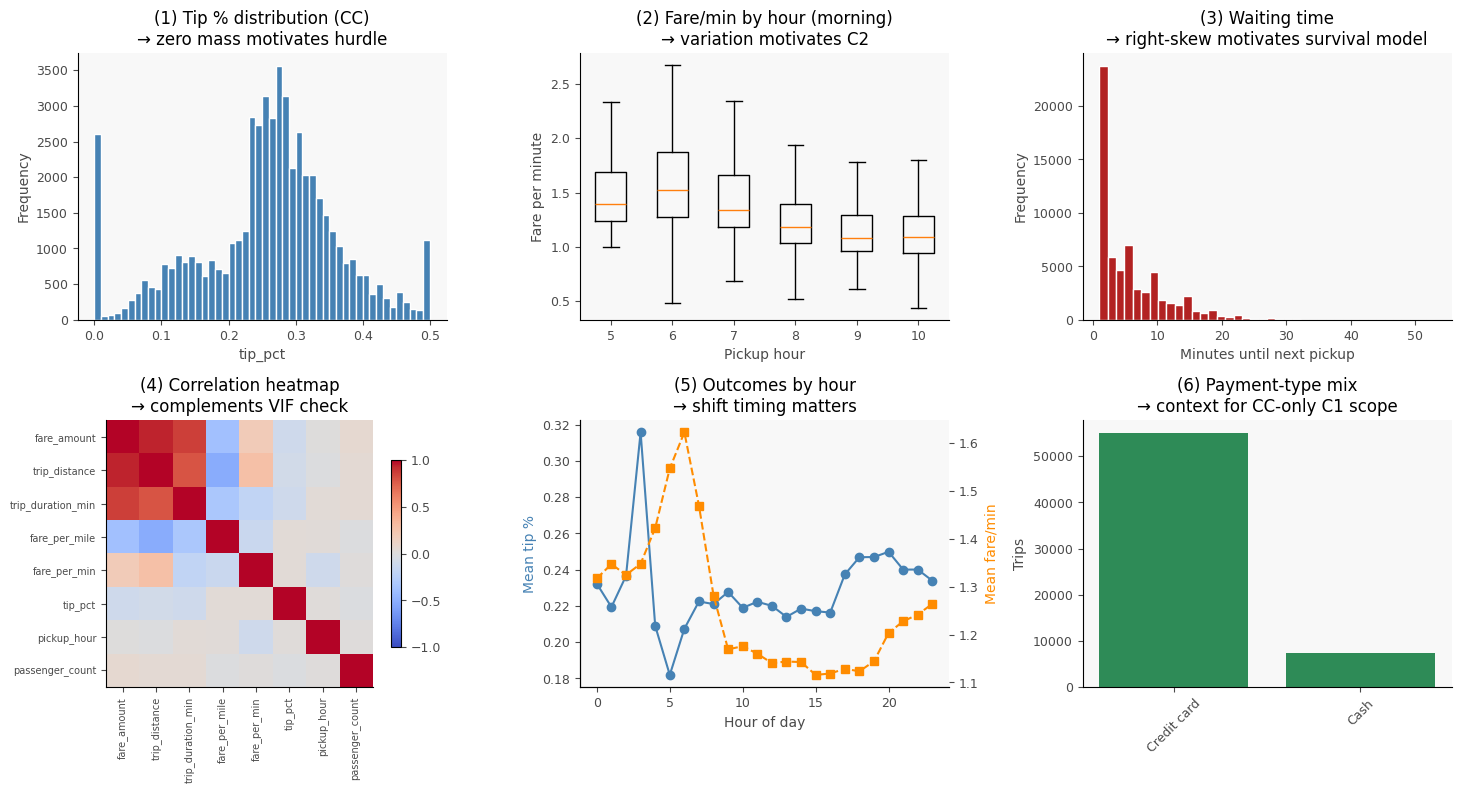

  EDA overview saved → eda_overview.png


In [ ]:
# ----------------------------------------------------------------
# EDA — Outcome Distributions & Patterns
# ----------------------------------------------------------------
# Five compact panels. Uses taxi_clean (post-cleaning) so the plots
# reflect the analysis sample. Each subplot is annotated to make the
# modelling motivation explicit for the report.
# ----------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# (1) Tip percentage distribution (CC trips) — zero inflation
cc = taxi_clean[taxi_clean['payment_type'] == 1]
axes[0, 0].hist(cc['tip_pct'].clip(upper=0.5), bins=50,
                color='steelblue', edgecolor='white')
axes[0, 0].set_title('(1) Tip % distribution (CC)\n→ zero mass motivates hurdle')
axes[0, 0].set_xlabel('tip_pct')
axes[0, 0].set_ylabel('Frequency')

# (2) Fare-per-minute by pickup hour (morning window)
morning = taxi_clean[taxi_clean['pickup_hour'].between(5, 10)]
hour_groups = [morning[morning['pickup_hour'] == h]['fare_per_min'].dropna()
               for h in range(5, 11)]
axes[0, 1].boxplot(hour_groups, labels=range(5, 11), showfliers=False)
axes[0, 1].set_title('(2) Fare/min by hour (morning)\n→ variation motivates C2')
axes[0, 1].set_xlabel('Pickup hour')
axes[0, 1].set_ylabel('Fare per minute')

# (3) Waiting-time distribution — right skew + censoring
# [FIX] Use est_empty_time from taxi_clean (available before c3_df is built)
wait_series = taxi_clean.loc[taxi_clean['est_empty_time'] > 0, 'est_empty_time'].dropna()
axes[0, 2].hist(wait_series.clip(upper=60), bins=40,
                color='firebrick', edgecolor='white')
axes[0, 2].set_title('(3) Waiting time\n→ right-skew motivates survival model')
axes[0, 2].set_xlabel('Minutes until next pickup')
axes[0, 2].set_ylabel('Frequency')

# (4) Correlation heatmap of key numeric features
num_feats = ['fare_amount', 'trip_distance', 'trip_duration_min',
             'fare_per_mile', 'fare_per_min', 'tip_pct',
             'pickup_hour', 'passenger_count']
num_feats = [f for f in num_feats if f in taxi_clean.columns]
corr = taxi_clean[num_feats].corr()
im = axes[1, 0].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1, 0].set_xticks(range(len(num_feats)))
axes[1, 0].set_xticklabels(num_feats, rotation=90, fontsize=7)
axes[1, 0].set_yticks(range(len(num_feats)))
axes[1, 0].set_yticklabels(num_feats, fontsize=7)
axes[1, 0].set_title('(4) Correlation heatmap\n→ complements VIF check')
fig.colorbar(im, ax=axes[1, 0], shrink=0.7)

# (5) Mean outcomes by hour-of-day (cross-cutting)
by_hour = taxi_clean.groupby('pickup_hour').agg(
    mean_tip=('tip_pct', 'mean'),
    mean_fare_min=('fare_per_min', 'mean'),
)
ax5 = axes[1, 1]
ax5.plot(by_hour.index, by_hour['mean_tip'], 'o-',
         color='steelblue', label='Mean tip %')
ax5.set_xlabel('Hour of day')
ax5.set_ylabel('Mean tip %', color='steelblue')
ax5b = ax5.twinx()
ax5b.plot(by_hour.index, by_hour['mean_fare_min'], 's--',
          color='darkorange', label='Mean fare/min')
ax5b.set_ylabel('Mean fare/min', color='darkorange')
ax5.set_title('(5) Outcomes by hour\n→ shift timing matters')

# (6) Payment-type composition (context for C1 scope)
pay_counts = taxi_clean['payment_type'].value_counts().sort_index()
pay_labels = {1: 'Credit card', 2: 'Cash', 3: 'No charge',
              4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
axes[1, 2].bar(
    [pay_labels.get(i, str(i)) for i in pay_counts.index],
    pay_counts.values, color='seagreen',
)
axes[1, 2].set_title('(6) Payment-type mix\n→ context for CC-only C1 scope')
axes[1, 2].set_ylabel('Trips')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("  EDA overview saved → eda_overview.png")


## PART 4. CHALLENGE SUBSETS & MULTICOLLINEARITY   

Each challenge uses a different analysis sample:

- **C1** (Tipping): credit-card-paying trips only — cash tips not recorded in TLC
- **C2** (Morning Launch): morning shift window (pickup hour 5–10)
- **C3** (Turnover Trap): waiting-spell observations (`est_empty_time > 0`)

Initial VIF check → drop variables with VIF > 10

### 4.1 Build Challenge Subsets

In [ ]:
# ----------------------------------------------------------------
# 4.1 Build Challenge Subsets (C1 / C2 / C3)
# ----------------------------------------------------------------

morning_mask      = taxi_clean['pickup_hour'].between(5, 10)
global_median_fpm = taxi_clean.loc[morning_mask, 'fare_per_min'].median()
global_p75_fpm    = taxi_clean.loc[morning_mask, 'fare_per_min'].quantile(0.75)

# ── C1: Credit card trips only ────────────────────────
c1_df = taxi_clean[taxi_clean['payment_type'] == 1].copy()
c1_df['tip_pct'] = (
    c1_df['tip_amount'] / c1_df['fare_amount']
).replace([np.inf, -np.inf], np.nan)

# ── C2: Morning trips ─────────────────────────────────
c2_df = taxi_clean[morning_mask].copy()
c2_df['trip_success']           = (c2_df['fare_per_min'] > global_median_fpm).astype(int)
c2_df['trip_success_p75']       = (c2_df['fare_per_min'] > global_p75_fpm).astype(int)
c2_df['trip_success_composite'] = (
    (c2_df['fare_per_min'] > global_median_fpm) &
    (c2_df['do_zone_quality'] > global_median_fpm)
).astype(int)

# ── C3: Waiting spells ────────────────────────────────
c3_df = taxi_clean[taxi_clean['est_empty_time'] > 0].copy()
c3_df['wait_duration']  = c3_df['est_empty_time']
c3_df['event_observed'] = c3_df['event_status'].fillna(0).astype(int)

print("\n=== CHALLENGE SUBSETS ===")
print(f"  C1 (credit card)   : {len(c1_df):,} | tip rate: {c1_df['tip_yes'].mean()*100:.1f}%")
print(f"  C2 (morning 5-10h) : {len(c2_df):,} | success: {c2_df['trip_success'].mean()*100:.1f}%")
print(f"  C3 (waiting spells): {len(c3_df):,} | event rate: {c3_df['event_observed'].mean()*100:.1f}%")
print(f"  Global median fpm  : ${global_median_fpm:.2f}/min")


=== CHALLENGE SUBSETS ===
  C1 (credit card)   : 55,053 | tip rate: 95.5%
  C2 (morning 5-10h) : 7,862 | success: 50.0%
  C3 (waiting spells): 62,316 | event rate: 83.5%
  Global median fpm  : $1.16/min


### 4.2–4.3 VIF Helper & Initial Check

In [ ]:
# ----------------------------------------------------------------
# 4.2 VIF Check — Helper Function
# ----------------------------------------------------------------

def check_vif(df, features, name):
    data = df[features].dropna()
    X    = sm.add_constant(data)
    vif  = pd.DataFrame({
        'Feature': features,
        'VIF'    : [variance_inflation_factor(X.values, i+1) for i in range(len(features))]
    }).sort_values('VIF', ascending=False)

    print(f"\n=== VIF: {name} ===")
    for _, row in vif.iterrows():
        flag = "🔴 DROP   " if row['VIF'] > 10 else ("🟡 CONCERN" if row['VIF'] > 5 else "✅")
        print(f"  {flag} {row['Feature']:40s}: {row['VIF']:.2f}")

    problems = vif[vif['VIF'] > 10]['Feature'].tolist()
    concerns = vif[(vif['VIF'] > 5) & (vif['VIF'] <= 10)]['Feature'].tolist()
    if problems: print(f"  → Drop candidates : {problems}")
    if concerns: print(f"  → Monitor closely : {concerns}")
    return vif

# ----------------------------------------------------------------
# 4.3 Initial VIF Check (All Candidate Features)
# ----------------------------------------------------------------

# C1 initial features — all vars with economic rationale
c1_features = [
    'log_fare', 'log_distance', 'trip_duration_min', 'fare_per_mile',
    'pickup_hour', 'is_weekend',
    'is_airport', 'congestion_surcharge', 'Airport_fee', 'log_tolls',
    'temperature_2m', 'bad_weather', 'snowfall',
    'passenger_count',
    'PU_Borough_grouped_Outer Boroughs', 'PU_Borough_grouped_Queens',
]

# C2 initial features
c2_features = [
    'pickup_hour', 'is_weekend',
    'is_airport', 'congestion_surcharge',
    'PU_Pop_1E', 'do_zone_quality',
    'bad_weather', 'temperature_2m', 'snowfall',
    'PU_Borough_grouped_Queens', 'PU_Borough_grouped_Outer Boroughs',
]

# C3 initial features
c3_features = [
    'pickup_hour', 'is_weekend',
    'is_airport', 'PU_Pop_1E',
    'bad_weather', 'temperature_2m', 'snowfall',
    'PU_Borough_grouped_Queens', 'PU_Borough_grouped_Outer Boroughs',
]

vif_c1 = check_vif(c1_df, c1_features, "C1 — Initial")
vif_c2 = check_vif(c2_df, c2_features, "C2 — Initial")
vif_c3 = check_vif(c3_df, c3_features, "C3 — Initial")


=== VIF: C1 — Initial ===
  🔴 DROP    log_distance                            : 28.17
  🔴 DROP    log_fare                                : 17.30
  🔴 DROP    PU_Borough_grouped_Queens               : 14.73
  🔴 DROP    Airport_fee                             : 13.54
  🟡 CONCERN trip_duration_min                       : 5.76
  ✅ fare_per_mile                           : 4.22
  ✅ log_tolls                               : 2.17
  ✅ is_airport                              : 1.78
  ✅ congestion_surcharge                    : 1.63
  ✅ bad_weather                             : 1.23
  ✅ snowfall                                : 1.19
  ✅ temperature_2m                          : 1.10
  ✅ is_weekend                              : 1.08
  ✅ pickup_hour                             : 1.07
  ✅ PU_Borough_grouped_Outer Boroughs       : 1.05
  ✅ passenger_count                         : 1.01
  → Drop candidates : ['log_distance', 'log_fare', 'PU_Borough_grouped_Queens', 'Airport_fee']
  → Monitor closel

### 4.4 Drop Collinear Variables & Re-check VIF

In [ ]:
# ----------------------------------------------------------------
# 4.4 Drop Collinear Variables & Re-check VIF
# ----------------------------------------------------------------

# C1 drops:
#   log_distance     VIF>10 — collinear with log_fare (r=0.92)
#   trip_duration_min VIF>5  — collinear with log_fare (r=0.89)
#   Airport_fee      VIF>10 — near-identical to Queens dummy (r=0.96)
#   Queens dummy     VIF>10 — captured by is_airport
#   in_congestion_zone      — 95.3% = 1, near-constant (no variation)
#   Outer Boroughs   — 99.7% = 0 in C1 (only 165 credit card trips)
#   congestion_surcharge    — replaced by log_tolls (more variation)
c1_features = [
    'log_fare', 'fare_per_mile',
    'pickup_hour', 'is_weekend',
    'is_airport',
    'log_tolls',
    'temperature_2m', 'bad_weather', 'snowfall',
    'passenger_count',
]

# C2 drops:
#   Outer Boroughs — not significant in morning trips context
# All VIF < 5 — no multicollinearity changes needed
c2_features = [
    'pickup_hour', 'is_weekend',
    'is_airport', 'congestion_surcharge',
    'PU_Pop_1E', 'do_zone_quality',
    'bad_weather', 'temperature_2m', 'snowfall',
    'PU_Borough_grouped_Queens',
]

# C3: All VIF < 5 — no changes needed
c3_features = [
    'pickup_hour', 'is_weekend',
    'is_airport', 'PU_Pop_1E',
    'bad_weather', 'temperature_2m', 'snowfall',
    'PU_Borough_grouped_Queens',
    'PU_Borough_grouped_Outer Boroughs',
]

# =====================================================
# RE-CHECK VIF AFTER DROPPING
# =====================================================
vif_c1_final = check_vif(c1_df, c1_features, "C1 — After Fix")
vif_c2_final = check_vif(c2_df, c2_features, "C2 — After Fix")
vif_c3_final = check_vif(c3_df, c3_features, "C3 — After Fix")


=== VIF: C1 — After Fix ===
  ✅ log_tolls                               : 1.67
  ✅ log_fare                                : 1.65
  ✅ is_airport                              : 1.51
  ✅ fare_per_mile                           : 1.24
  ✅ bad_weather                             : 1.23
  ✅ snowfall                                : 1.19
  ✅ temperature_2m                          : 1.10
  ✅ is_weekend                              : 1.07
  ✅ pickup_hour                             : 1.07
  ✅ passenger_count                         : 1.01

=== VIF: C2 — After Fix ===
  ✅ PU_Borough_grouped_Queens               : 2.18
  ✅ congestion_surcharge                    : 1.85
  ✅ bad_weather                             : 1.55
  ✅ do_zone_quality                         : 1.44
  ✅ snowfall                                : 1.44
  ✅ PU_Pop_1E                               : 1.35
  ✅ is_airport                              : 1.26
  ✅ temperature_2m                          : 1.09
  ✅ is_weekend          

## PART 5. CHALLENGE 1 — WHAT DRIVES TIPPING?

### Research question
What trip-level, temporal, spatial, and contextual factors drive (a) the decision to tip, and (b) the size of the tip, among credit-card paying riders in NYC Yellow Cabs?

### Modelling rationale — Two-part Hurdle
Tipping behaviour exhibits two structurally distinct decisions — *whether* to tip (binary) and *how much* (continuous, strictly positive) — that may be governed by different processes. This motivates a **two-part hurdle (Cragg 1971)**:

- **Stage 1** — Logit for participation (`tip_yes`)
- **Stage 2** — Gamma GLM with log link for the amount conditional on participation (`tip_pct | tip > 0`). Gamma is appropriate for right-skewed strictly-positive outcomes (Leeflang et al. 2015, *Modelling Markets*, Ch. on limited dependent variables).

### Sample scope
Credit-card trips only (`payment_type == 1`); cash tips are not recorded in the TLC schema. **Selection bias** between CC and cash trips is quantified in §5.0 via standardized mean differences (Stuart 2010).


### References
- Cragg, J. G. (1971). *Econometrica*, 39(5).
- Vuong, Q. H. (1989). *Econometrica*, 57(2).
- Leeflang, P. S. H. et al. (2015). *Modeling Markets*.
- Leliveld, M. C. & Risselada, H. (2017). *J. Bus. Res.*
- Bayart, C. et al. (2018) on hurdle models for tipping.
- Cameron, A. C. & Miller, D. L. (2015). *J. Human Res.*, 50(2).

### 5.1–5.2 Sample Preparation & Distribution Checks   

In [ ]:
# ----------------------------------------------------------------
# 5.1 Prepare Samples (Stage 1 & Stage 2)
# ----------------------------------------------------------------


# MODIFIED: include PULocationID for cluster-robust SEs in §5.3-5.4
c1_s1 = c1_df[c1_features + ['tip_yes', 'tip_pct', 'PULocationID']].dropna()
c1_s2 = c1_s1[c1_s1['tip_yes'] == 1].copy()

print(f"\n=== C1 SAMPLE SIZES ===")
print(f"  Stage 1 (all CC trips) : {len(c1_s1):,}")
print(f"  Stage 2 (tipped only)  : {len(c1_s2):,} ({len(c1_s2)/len(c1_s1)*100:.1f}%)")

# ----------------------------------------------------------------
# 5.2 Distribution & Skewness Check
# ----------------------------------------------------------------

print("\n=== C1 SKEWNESS CHECK ===")

# DV checks
tip_yes_rate = c1_s1['tip_yes'].mean()
tip_pct_skew = c1_s2['tip_pct'].skew()

print(f"\n  --- Dependent Variables ---")
print(f"  tip_yes rate : {tip_yes_rate*100:.1f}%  "
      f"{'⚠️  Imbalanced — pre-filled tip screen artifact' if tip_yes_rate > 0.9 else '✅'}")
print(f"  tip_pct skew : {tip_pct_skew:.2f}  "
      f"{'✅ Right-skewed → Gamma GLM appropriate' if tip_pct_skew > 1 else '🟡 Check distribution'}")

# Predictor checks
print(f"\n  --- Key Predictors ---")
print(f"  {'Variable':25s}  {'Skew':>8}  {'Treatment'}")
print(f"  {'-'*60}")

predictor_checks = {
    'log_fare'       : 'already log-transformed — acceptable',
    'fare_per_mile'  : 'moderate skew — acceptable for GLM',
    'log_tolls'      : 'log1p applied — residual skew acceptable',
    'passenger_count': 'discrete (1–6) — no transform needed',
    'temperature_2m' : 'continuous — check',
    'snowfall'       : 'zero-inflated — binary bad_weather captures effect',
    'bad_weather'    : 'binary — no transform needed',
    'pickup_hour'    : 'discrete ordinal — no transform needed',
    'is_weekend'     : 'binary — no transform needed',
    'is_airport'     : 'binary — no transform needed',
}

for col, note in predictor_checks.items():
    if col in c1_s1.columns:
        skew = c1_s1[col].skew()
        flag = ("⚠️ " if abs(skew) > 2 and
                col not in ['log_fare','log_tolls','bad_weather',
                            'is_weekend','is_airport','pickup_hour',
                            'passenger_count']
                else "✅")
        print(f"  {flag} {col:25s}  {skew:+8.3f}  {note}")

# Gamma GLM validity check
print(f"\n  --- Gamma GLM Validity (Stage 2) ---")
print(f"  tip_pct > 0 (all)  : {(c1_s2['tip_pct'] > 0).all()}  "
      f"{'✅ Required for Gamma' if (c1_s2['tip_pct'] > 0).all() else '❌ Has zeros — use Tobit instead'}")
print(f"  tip_pct min        : {c1_s2['tip_pct'].min():.6f}")
print(f"  tip_pct mean       : {c1_s2['tip_pct'].mean():.4f}")
print(f"  tip_pct skew       : {tip_pct_skew:.2f} → "
      f"{'Gamma appropriate ✅' if tip_pct_skew > 1 else 'Consider log-OLS as robustness'}")




=== C1 SAMPLE SIZES ===
  Stage 1 (all CC trips) : 55,053
  Stage 2 (tipped only)  : 52,549 (95.5%)

=== C1 SKEWNESS CHECK ===

  --- Dependent Variables ---
  tip_yes rate : 95.5%  ⚠️  Imbalanced — pre-filled tip screen artifact
  tip_pct skew : 7.49  ✅ Right-skewed → Gamma GLM appropriate

  --- Key Predictors ---
  Variable                       Skew  Treatment
  ------------------------------------------------------------
  ✅ log_fare                     +0.800  already log-transformed — acceptable
  ✅ fare_per_mile                +1.788  moderate skew — acceptable for GLM
  ✅ log_tolls                    +3.567  log1p applied — residual skew acceptable
  ✅ passenger_count              +3.510  discrete (1–6) — no transform needed
  ✅ temperature_2m               -0.746  continuous — check
  ⚠️  snowfall                    +13.375  zero-inflated — binary bad_weather captures effect
  ✅ bad_weather                  +2.943  binary — no transform needed
  ✅ pickup_hour                

### 5.3 Stage 1 — Logit: P(tip > 0)  

In [ ]:
# ----------------------------------------------------------------
# 5.3 Stage 1 — Logit: P(tip > 0)
# ----------------------------------------------------------------

X1 = sm.add_constant(c1_s1[c1_features])
y1 = c1_s1['tip_yes']

print("\n>>> Stage 1: Logit (tip yes/no)...")
# MODIFIED: cluster-robust SEs at pickup-zone level
logit_s1 = sm.Logit(y1, X1).fit(
    cov_type='cluster',
    cov_kwds={'groups': c1_s1['PULocationID'].values},
    maxiter=200,
)
me_s1    = logit_s1.get_margeff()
print(logit_s1.summary())

me_s1_df = me_s1.summary_frame()[['dy/dx', 'Pr(>|z|)']].round(4)
me_s1_df.columns = ['ME', 'p_value']
me_s1_df['sig'] = me_s1_df['p_value'].apply(
    lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
)
print(f"  Pseudo R²: {logit_s1.prsquared:.4f} | AIC: {logit_s1.aic:.1f}")
print("\n=== STAGE 1: MARGINAL EFFECTS ===")
print(me_s1_df.to_string())



>>> Stage 1: Logit (tip yes/no)...
Optimization terminated successfully.
         Current function value: 0.183399
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                tip_yes   No. Observations:                55053
Model:                          Logit   Df Residuals:                    55042
Method:                           MLE   Df Model:                           10
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                0.008629
Time:                        16:18:30   Log-Likelihood:                -10097.
converged:                       True   LL-Null:                       -10185.
Covariance Type:              cluster   LLR p-value:                 1.767e-32
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.4683      0.216     16.049      0.000   

### 5.4 Stage 2 — Gamma GLM: E(tip_pct | tipped)   

In [ ]:
# ----------------------------------------------------------------
# 5.4 Stage 2 — Gamma GLM: E(tip_pct | tipped)
# ----------------------------------------------------------------

X2 = sm.add_constant(c1_s2[c1_features])
y2 = c1_s2['tip_pct']

print("\n>>> Stage 2: Gamma GLM (tip_pct | tipped)...")
# MODIFIED: cluster-robust SEs at pickup-zone level
gamma_s2 = sm.GLM(
    y2, X2,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit(
    cov_type='cluster',
    cov_kwds={'groups': c1_s2['PULocationID'].values},
)

gamma_df = pd.DataFrame({
    'coef'   : gamma_s2.params[1:].round(4),
    'ME'     : (gamma_s2.params[1:] * y2.mean()).round(4),
    'p_value': gamma_s2.pvalues[1:].round(3),
    'sig'    : gamma_s2.pvalues[1:].apply(
        lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    )
}, index=c1_features)

print(f"  AIC: {gamma_s2.aic:.1f} | Mean tip_pct: {y2.mean():.4f}")
print("\n=== STAGE 2: GAMMA COEFFICIENTS ===")
print(gamma_df.to_string())


>>> Stage 2: Gamma GLM (tip_pct | tipped)...
  AIC: -91707.5 | Mean tip_pct: 0.2721

=== STAGE 2: GAMMA COEFFICIENTS ===
                   coef      ME  p_value  sig
log_fare        -0.3105 -0.0845    0.000  ***
fare_per_mile    0.0015  0.0004    0.104     
pickup_hour      0.0024  0.0007    0.000  ***
is_weekend      -0.0215 -0.0059    0.000  ***
is_airport      -0.0038 -0.0010    0.898     
log_tolls        0.1401  0.0381    0.000  ***
temperature_2m   0.0009  0.0002    0.014   **
bad_weather     -0.0012 -0.0003    0.864     
snowfall         0.0461  0.0125    0.124     
passenger_count  0.0013  0.0004    0.638     


### 5.5 Cragg's LR Test (Hurdle vs Tobit)  

**This replaces the ad-hoc log-likelihood comparison from the prior version.**

#### Cragg (1971) LR test
$$LR = 2 \cdot (\ell_{\text{hurdle}} - \ell_{\text{tobit}}) \sim \chi^2_{\Delta k}$$
where $\Delta k$ is the difference in number of parameters. **Reject H₀** ⇒ the two-part structure provides additional explanatory power beyond Tobit's single-process specification.

In [ ]:
# ----------------------------------------------------------------
# 5.5 Cragg's LR Test (Hurdle vs Tobit)
# ----------------------------------------------------------------

# --- Fit Tobit (Type I, left-censored at zero) ---
class TobitTypeI:
    def __init__(self, y, X):
        self.y = np.asarray(y, dtype=float)
        self.X = np.asarray(X, dtype=float)
        self.censored = (self.y == 0)

    def _nll(self, theta):
        beta, sigma = theta[:-1], np.exp(theta[-1])
        xb = self.X @ beta
        ll  = sps.norm.logcdf(-xb[self.censored] / sigma).sum()
        z   = (self.y[~self.censored] - xb[~self.censored]) / sigma
        ll += (sps.norm.logpdf(z) - np.log(sigma)).sum()
        return -ll

    def fit(self):
        b0, *_ = np.linalg.lstsq(self.X, self.y, rcond=None)
        s0     = max(self.y[~self.censored].std(), 1e-3)
        res    = optimize.minimize(self._nll,
                                   np.append(b0, np.log(s0)),
                                   method='BFGS')
        self.llf      = -res.fun
        self.n_params = len(res.x)
        return self

tobit = TobitTypeI(c1_s1['tip_pct'].fillna(0), X1.values).fit()

# --- Cragg's LR test ---
ll_hurdle = logit_s1.llf + gamma_s2.llf
k_hurdle  = len(logit_s1.params) + len(gamma_s2.params)
k_tobit   = tobit.n_params

LR = 2 * (ll_hurdle - tobit.llf)
df = k_hurdle - k_tobit
p  = 1 - sps.chi2.cdf(LR, df)

print("=== CRAGG'S LR TEST (Hurdle vs Tobit) ===")
print(f"  LL Hurdle (joint)  : {ll_hurdle:.2f}  (k={k_hurdle})")
print(f"  LL Tobit           : {tobit.llf:.2f}  (k={k_tobit})")
print(f"  LR statistic       : {LR:.2f}")
print(f"  Degrees of freedom : {df}")
print(f"  p-value            : {p:.4g}")
print(f"  → {'Reject H0 — hurdle preferred ✅' if p < 0.05 else 'Fail to reject — Tobit adequate'}")

=== CRAGG'S LR TEST (Hurdle vs Tobit) ===
  LL Hurdle (joint)  : 35768.10  (k=22)
  LL Tobit           : 31361.66  (k=12)
  LR statistic       : 8812.88
  Degrees of freedom : 10
  p-value            : 0
  → Reject H0 — hurdle preferred ✅


### 5.6 Subgroup Robustness — Airport / Weekday   

Stage-1 logit re-estimated on (i) airport vs non-airport and (ii) weekday vs weekend subsets to verify result stability.

In [ ]:
# ----------------------------------------------------------------
# 5.6 Robustness — Airport vs Non-airport
# ----------------------------------------------------------------

print("\n=== ROBUSTNESS: Airport vs Non-airport ===")
for label, mask in [('Airport', c1_s1['is_airport']==1),
                    ('Non-airport', c1_s1['is_airport']==0)]:
    sub   = c1_s1[mask]
    feats = [f for f in c1_features if f != 'is_airport' and sub[f].nunique() > 1]
    try:
        m  = sm.Logit(sub['tip_yes'], sm.add_constant(sub[feats])).fit(disp=0)
        me = m.get_margeff().summary_frame()
        sig = me[me['Pr(>|z|)'] < 0.05][['dy/dx', 'Pr(>|z|)']].round(4)
        print(f"\n  [{label}] n={len(sub):,} | R²={m.prsquared:.4f}")
        print(sig.to_string() if len(sig) else "    No significant vars")
    except Exception:
        lpm = sm.OLS(sub['tip_yes'], sm.add_constant(sub[feats])).fit(cov_type='HC3')
        sig = lpm.pvalues[lpm.pvalues < 0.05].drop('const', errors='ignore')
        print(f"\n  [{label}] n={len(sub):,} → LPM fallback")
        for v, p in sig.items():
            print(f"    {v}: coef={lpm.params[v]:+.4f} (p={p:.3f})")

# ----------------------------------------------------------------
# 5.7 Robustness — Weekday vs Weekend
# ----------------------------------------------------------------

print("\n=== ROBUSTNESS: Weekday vs Weekend ===")
for label, mask in [('Weekday', c1_s1['is_weekend']==0),
                    ('Weekend', c1_s1['is_weekend']==1)]:
    sub   = c1_s1[mask]
    feats = [f for f in c1_features if f != 'is_weekend' and sub[f].nunique() > 1]
    try:
        m  = sm.Logit(sub['tip_yes'], sm.add_constant(sub[feats])).fit(disp=0)
        me = m.get_margeff().summary_frame()
        sig = me[me['Pr(>|z|)'] < 0.05][['dy/dx', 'Pr(>|z|)']].round(4)
        print(f"\n  [{label}] n={len(sub):,} | R²={m.prsquared:.4f}")
        print(sig.to_string() if len(sig) else "    No significant vars")
    except Exception:
        lpm = sm.OLS(sub['tip_yes'], sm.add_constant(sub[feats])).fit(cov_type='HC3')
        sig = lpm.pvalues[lpm.pvalues < 0.05].drop('const', errors='ignore')
        print(f"\n  [{label}] n={len(sub):,} → LPM fallback")
        for v, p in sig.items():
            print(f"    {v}: coef={lpm.params[v]:+.4f} (p={p:.3f})")



=== ROBUSTNESS: Airport vs Non-airport ===

  [Airport] n=1,790 | R²=0.0228
                  dy/dx  Pr(>|z|)
passenger_count -0.0109    0.0479

  [Non-airport] n=53,263 | R²=0.0093
                  dy/dx  Pr(>|z|)
log_fare        -0.0042    0.0229
fare_per_mile   -0.0016    0.0000
pickup_hour      0.0011    0.0000
is_weekend      -0.0149    0.0000
passenger_count -0.0045    0.0005

=== ROBUSTNESS: Weekday vs Weekend ===

  [Weekday] n=39,982 | R²=0.0030
                  dy/dx  Pr(>|z|)
fare_per_mile   -0.0010    0.0001
pickup_hour      0.0006    0.0006
snowfall        -0.0375    0.0119
passenger_count -0.0040    0.0068

  [Weekend] n=15,071 | R²=0.0159
                  dy/dx  Pr(>|z|)
log_fare        -0.0134    0.0003
fare_per_mile   -0.0036    0.0000
pickup_hour      0.0020    0.0000
passenger_count -0.0060    0.0139


### 5.8 C1 Results Summary   

In [ ]:
# ----------------------------------------------------------------
# 5.8 Results Summary
# ----------------------------------------------------------------

print("\n" + "="*50)
print("C1 RESULTS SUMMARY")
print("="*50)
print(f"  Model  : Two-part Hurdle | HC3 robust SEs")
print(f"  Stage 1: Logit | Pseudo R²={logit_s1.prsquared:.4f} | N={int(logit_s1.nobs):,}")
print(f"  Stage 2: Gamma GLM | AIC={gamma_s2.aic:.1f} | N={int(gamma_s2.nobs):,}")
print("\n  Stage 1 significant (p<0.05):")
print(me_s1_df[me_s1_df['p_value']<0.05].sort_values('ME', ascending=False).to_string())
print("\n  Stage 2 significant (p<0.05):")
print(gamma_df[gamma_df['p_value']<0.05].sort_values('ME', ascending=False).to_string())



C1 RESULTS SUMMARY
  Model  : Two-part Hurdle | HC3 robust SEs
  Stage 1: Logit | Pseudo R²=0.0086 | N=55,053
  Stage 2: Gamma GLM | AIC=-91707.5 | N=52,549

  Stage 1 significant (p<0.05):
                     ME  p_value  sig
pickup_hour      0.0011   0.0000  ***
fare_per_mile   -0.0016   0.0000  ***
passenger_count -0.0048   0.0004  ***
is_weekend      -0.0141   0.0000  ***

  Stage 2 significant (p<0.05):
                  coef      ME  p_value  sig
log_tolls       0.1401  0.0381    0.000  ***
pickup_hour     0.0024  0.0007    0.000  ***
temperature_2m  0.0009  0.0002    0.014   **
is_weekend     -0.0215 -0.0059    0.000  ***
log_fare       -0.3105 -0.0845    0.000  ***


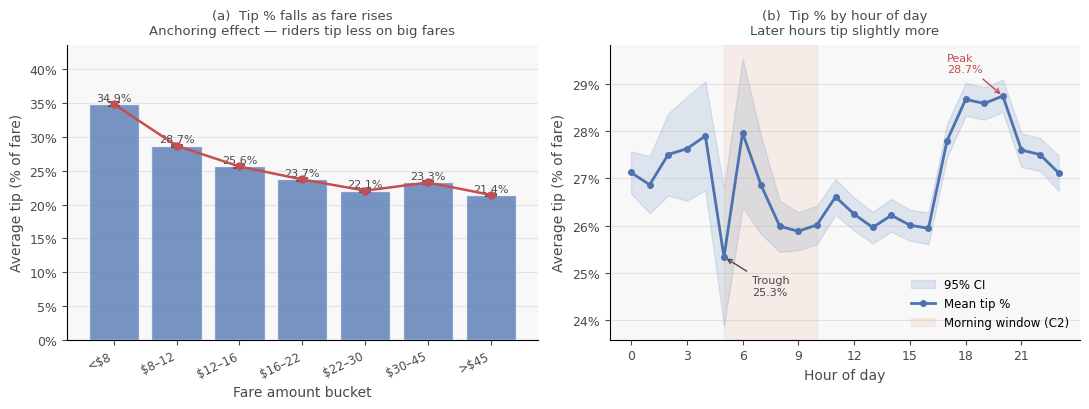

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Challenge 1: Tip % patterns (fare bucket + hour of day)
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Prep: CC tipped trips only ────────────────────────────────────
cc = taxi_clean[(taxi_clean["payment_type"] == 1) &
                (taxi_clean["tip_amount"] > 0)].copy()
cc["tip_pct_plot"] = (cc["tip_amount"] / cc["fare_amount"].replace(0, np.nan)).clip(upper=1.0)

# ── Fare buckets ──────────────────────────────────────────────────
bins   = [0, 8, 12, 16, 22, 30, 45, 200]
labels = ["<$8", "$8–12", "$12–16", "$16–22", "$22–30", "$30–45", ">$45"]
cc["fare_bucket"] = pd.cut(cc["fare_amount"], bins=bins, labels=labels)

fare_grp = cc.groupby("fare_bucket", observed=True)["tip_pct_plot"].agg(
    mean="mean",
    sem=lambda x: x.std() / np.sqrt(len(x))
).reset_index()

# ── Hourly tip % ──────────────────────────────────────────────────
hour_grp = cc.groupby("pickup_hour")["tip_pct_plot"].agg(
    mean="mean",
    sem=lambda x: x.std() / np.sqrt(len(x))
).reset_index()

# ── Style ─────────────────────────────────────────────────────────
GREY   = "#4a4a4a"
BLUE   = "#4C72B0"
RED    = "#C44E52"
ORANGE = "#DD8452"

plt.rcParams.update({
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.facecolor":    "#f8f8f8",
    "figure.facecolor":  "white",
    "axes.labelcolor":   GREY,
    "xtick.color":       GREY,
    "ytick.color":       GREY,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
fig.subplots_adjust(wspace=0.40, left=0.08, right=0.97, top=0.87, bottom=0.16)

# ── Panel (a): Tip % by fare bucket ──────────────────────────────
x    = np.arange(len(fare_grp))
bars = ax1.bar(x, fare_grp["mean"] * 100,
               yerr=fare_grp["sem"] * 100 * 1.96,
               color=BLUE, alpha=0.75, edgecolor="white",
               error_kw=dict(ecolor=GREY, lw=1.2, capsize=4, capthick=1.2),
               zorder=3)
ax1.plot(x, fare_grp["mean"] * 100,
         color=RED, lw=1.8, marker="o", ms=5, zorder=4)

ax1.set_xticks(x)
ax1.set_xticklabels(fare_grp["fare_bucket"], rotation=25, ha="right", fontsize=8.5)
ax1.set_xlabel("Fare amount bucket")
ax1.set_ylabel("Average tip (% of fare)")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax1.set_title("(a)  Tip % falls as fare rises\nAnchoring effect — riders tip less on big fares",
              fontsize=9.5, color=GREY, pad=8)
ax1.grid(axis="y", alpha=0.3, zorder=0)
ax1.set_ylim(0, fare_grp["mean"].max() * 100 * 1.25)

for bar, val in zip(bars, fare_grp["mean"] * 100):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=8, color=GREY)

# ── Panel (b): Tip % by hour ──────────────────────────────────────
ax2.fill_between(hour_grp["pickup_hour"],
                 (hour_grp["mean"] - 1.96 * hour_grp["sem"]) * 100,
                 (hour_grp["mean"] + 1.96 * hour_grp["sem"]) * 100,
                 color=BLUE, alpha=0.15, label="95% CI")
ax2.plot(hour_grp["pickup_hour"], hour_grp["mean"] * 100,
         color=BLUE, lw=2, marker="o", ms=4, zorder=4, label="Mean tip %")
ax2.axvspan(5, 10, color=ORANGE, alpha=0.10, label="Morning window (C2)")

imax = hour_grp["mean"].idxmax()
imin = hour_grp["mean"].idxmin()
ax2.annotate(f"Peak\n{hour_grp.loc[imax, 'mean'] * 100:.1f}%",
             xy=(hour_grp.loc[imax, "pickup_hour"],
                 hour_grp.loc[imax, "mean"] * 100),
             xytext=(hour_grp.loc[imax, "pickup_hour"] - 3,
                     hour_grp.loc[imax, "mean"] * 100 + 0.5),
             fontsize=8, color=RED,
             arrowprops=dict(arrowstyle="->", color=RED, lw=1))
ax2.annotate(f"Trough\n{hour_grp.loc[imin, 'mean'] * 100:.1f}%",
             xy=(hour_grp.loc[imin, "pickup_hour"],
                 hour_grp.loc[imin, "mean"] * 100),
             xytext=(hour_grp.loc[imin, "pickup_hour"] + 1.5,
                     hour_grp.loc[imin, "mean"] * 100 - 0.8),
             fontsize=8, color=GREY,
             arrowprops=dict(arrowstyle="->", color=GREY, lw=1))

ax2.set_xlabel("Hour of day")
ax2.set_ylabel("Average tip (% of fare)")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax2.set_title("(b)  Tip % by hour of day\nLater hours tip slightly more",
              fontsize=9.5, color=GREY, pad=8)
ax2.set_xticks(range(0, 24, 3))
ax2.grid(axis="y", alpha=0.3, zorder=0)
ax2.legend(fontsize=8.5, frameon=False, loc="lower right")


plt.tight_layout()
plt.show()

## PART 6. CHALLENGE 2 — THE MORNING LAUNCH

### Research question
Where should a driver start their shift to maximise earnings-per-minute during the 05:00–10:00 window?

### Modelling rationale — Binary Logit
Binary outcome (`trip_success = 1` if fare-per-minute exceeds the **global** morning median) is modelled via binary logit. We use the global (not zone-relative) median to preserve cross-zone comparability — a zone-relative threshold mechanically neutralises zone differences and would undermine the actionability of any subsequent ranking (Mai et al. 2021).

### On fixed effects
We deliberately do **not** include pickup-zone fixed effects. Reasons:

1. **Incidental-parameters problem** in nonlinear models with many FE (Greene 2004) — even with n = 100k, ~200 zone FEs introduce finite-sample bias in logit coefficients.
2. **Actionability** — drivers cannot internalise hundreds of zone-specific betas; the output must be ranked recommendations.

### 6.1–6.2 Sample Preparation & Main Logit   


In [ ]:
# ----------------------------------------------------------------
# 6.1 Prepare Model Data
# ----------------------------------------------------------------

c2_model_df = c2_df[c2_features + [
    'trip_success', 'trip_success_p75', 'trip_success_composite',
    'PULocationID',
]].dropna()

X_c2 = sm.add_constant(c2_model_df[c2_features])
y_c2 = c2_model_df['trip_success']

print(f"\n=== C2 MODEL DATA ===")
print(f"  N={len(c2_model_df):,} | Success rate: {y_c2.mean()*100:.1f}%")

# ----------------------------------------------------------------
# 6.2 Main Model — Binary Logit
# ----------------------------------------------------------------

print("\n>>> Binary Logit (main model)...")

logit_c2 = sm.Logit(y_c2, X_c2).fit(
    cov_type='cluster',
    cov_kwds={'groups': c2_model_df['PULocationID'].values},
    maxiter=200,
)
me_c2    = logit_c2.get_margeff()

print(logit_c2.summary())

me_c2_df = me_c2.summary_frame()[['dy/dx', 'Pr(>|z|)']].round(4)
me_c2_df.columns = ['ME', 'p_value']
me_c2_df['sig'] = me_c2_df['p_value'].apply(
    lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
)
print(f"  Pseudo R²: {logit_c2.prsquared:.4f} | AIC: {logit_c2.aic:.1f}")
print("\n=== C2 MARGINAL EFFECTS ===")
print(me_c2_df.to_string())

# ----------------------------------------------------------------
# 6.3 Model Fit (AUC, Brier Score)
# ----------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_c2, y_c2, test_size=0.3, random_state=42
)
logit_train = sm.Logit(y_train, X_train).fit(disp=0)
y_pred      = logit_train.predict(X_test)

auc   = roc_auc_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_pred)

print("\n=== C2 MODEL FIT ===")
print(f"  Pseudo R²   : {logit_c2.prsquared:.4f}")
print(f"  AUC         : {auc:.4f}  (baseline = 0.50)")
print(f"  Brier score : {brier:.4f}  (baseline = 0.25)")
print(f"  AIC         : {logit_c2.aic:.1f}")
print(f"  BIC         : {logit_c2.bic:.1f}")
print(f"  Log-Lik     : {logit_c2.llf:.1f}")
print(f"  N           : {int(logit_c2.nobs):,}")


=== C2 MODEL DATA ===
  N=7,862 | Success rate: 50.0%

>>> Binary Logit (main model)...
Optimization terminated successfully.
         Current function value: 0.565025
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           trip_success   No. Observations:                 7862
Model:                          Logit   Df Residuals:                     7851
Method:                           MLE   Df Model:                           10
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                  0.1848
Time:                        16:18:40   Log-Likelihood:                -4442.2
converged:                       True   LL-Null:                       -5449.5
Covariance Type:              cluster   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

### 6.4–6.7 LPM Robustness, DV Sensitivity, Subsample, Descriptive Zone Rankings   

Original block kept intact — the LPM/sensitivity/subsample logic is sound and the descriptive zone ranking remains useful as a sanity check against the model-based ranking in §6.8.

In [ ]:
# ----------------------------------------------------------------
# 6.4 Robustness 1 — LPM Comparison
# ----------------------------------------------------------------

lpm_c2     = sm.OLS(y_c2, X_c2).fit(cov_type='HC3')
compare_df = pd.DataFrame({
    'Logit_ME': me_c2.margeff.round(4),
    'LPM_coef': lpm_c2.params[1:].round(4),
    'Logit_p' : me_c2.pvalues.round(3),
    'LPM_p'   : lpm_c2.pvalues[1:].round(3),
}, index=c2_features)
compare_df['same_sign'] = (
    np.sign(compare_df['Logit_ME']) == np.sign(compare_df['LPM_coef'])
)
print(f"\n=== LPM ROBUSTNESS ===")
print(compare_df.to_string())
print(f"Same sign: {compare_df['same_sign'].sum()}/{len(compare_df)}")

# ----------------------------------------------------------------
# 6.5 Robustness 2 — DV Definition Sensitivity
# ----------------------------------------------------------------

print("\n=== DV SENSITIVITY ===")
for dv, label in [
    ('trip_success',           'Main (global median)'),
    ('trip_success_p75',       'Strict (global p75)'),
    ('trip_success_composite', 'Composite (fare + dropoff)'),
]:
    m  = sm.Logit(c2_model_df[dv], X_c2).fit(disp=0, maxiter=200)
    me = m.get_margeff().summary_frame()
    sig = me[me['Pr(>|z|)'] < 0.05][['dy/dx', 'Pr(>|z|)']].round(4)
    print(f"\n  [{label}] R²={m.prsquared:.4f} | N(success)={c2_model_df[dv].sum():,}")
    print(sig.to_string() if len(sig) else "    No significant vars")

# ----------------------------------------------------------------
# 6.6 Robustness 3 — Weekday vs Weekend Subsample
# ----------------------------------------------------------------

print("\n=== SUBSAMPLE: WEEKDAY vs WEEKEND ===")
for label, mask in [('Weekday', c2_model_df['is_weekend']==0),
                    ('Weekend', c2_model_df['is_weekend']==1)]:
    sub   = c2_model_df[mask]
    feats = [f for f in c2_features if f != 'is_weekend' and sub[f].nunique() > 1]
    try:
        m  = sm.Logit(sub['trip_success'], sm.add_constant(sub[feats])).fit(disp=0)
        me = m.get_margeff().summary_frame()
        sig = me[me['Pr(>|z|)'] < 0.05][['dy/dx', 'Pr(>|z|)']].round(4)
        print(f"\n  [{label}] n={len(sub):,} | R²={m.prsquared:.4f} | success={sub['trip_success'].mean()*100:.1f}%")
        print(sig.to_string() if len(sig) else "    No significant vars")
    except Exception:
        lpm = sm.OLS(sub['trip_success'], sm.add_constant(sub[feats])).fit(cov_type='HC3')
        sig = lpm.pvalues[lpm.pvalues < 0.05].drop('const', errors='ignore')
        print(f"\n  [{label}] n={len(sub):,} → LPM fallback")
        for v, p in sig.items():
            print(f"    {v}: coef={lpm.params[v]:+.4f} (p={p:.3f})")

# ----------------------------------------------------------------
# 6.7 Zone Rankings
# ----------------------------------------------------------------

zone_ref = taxi_final[['PULocationID','PU_Zone','PU_Borough']].drop_duplicates()

zone_summary = (
    c2_df.groupby('PULocationID')
    .agg(n_trips=('trip_success','count'),
         success_rate=('trip_success','mean'),
         avg_fpm=('fare_per_min','mean'),
         do_quality=('do_zone_quality','mean'))
    .reset_index()
    .query('n_trips >= 20')
    .merge(zone_ref, on='PULocationID', how='left')
    .sort_values('success_rate', ascending=False)
)

print("\n=== TOP 10 MORNING ZONES ===")
print(zone_summary[['PU_Zone','PU_Borough','n_trips','success_rate','avg_fpm','do_quality']]
      .head(10).round(3).to_string(index=False))

print("\n=== BOTTOM 10 MORNING ZONES ===")
print(zone_summary[['PU_Zone','PU_Borough','n_trips','success_rate','avg_fpm','do_quality']]
      .tail(10).round(3).to_string(index=False))


=== LPM ROBUSTNESS ===
                           Logit_ME  LPM_coef  Logit_p  LPM_p  same_sign
pickup_hour                 -0.1017   -0.0932    0.000  0.000       True
is_weekend                   0.3652    0.3351    0.000  0.000       True
is_airport                  -0.0139    0.0497    0.764  0.064      False
congestion_surcharge        -0.0058   -0.0126    0.694  0.234       True
PU_Pop_1E                    0.0012    0.0015    0.001  0.000       True
do_zone_quality              0.9306    0.5041    0.000  0.000       True
bad_weather                 -0.0236   -0.0085    0.265  0.671       True
temperature_2m               0.0039    0.0032    0.002  0.002       True
snowfall                    -0.0645   -0.0879    0.389  0.149       True
PU_Borough_grouped_Queens    0.1446    0.1176    0.009  0.000       True
Same sign: 9/10

=== DV SENSITIVITY ===

  [Main (global median)] R²=0.1848 | N(success)=3,931
                            dy/dx  Pr(>|z|)
pickup_hour               -0.1017 

### 6.8 Model-Based Zone Rankings + Calibration Plot   

#### Why model-based ranking?
The descriptive ranking in §6.7 (raw success rate per zone) is **confounded**: a zone may appear "good" simply because trips there tend to happen at peak hours, on weekdays, in clear weather. To answer the question "*conditional on other factors, which zone is best?*" we compute predicted P(success) under a **standardised scenario** (median covariates, weekday, clear weather) and rank zones accordingly.

If the correlation between descriptive and model-based ranks is high (>0.85), the simpler descriptive ranking is defensible. If lower, the model-based ranking is the methodologically correct advice.

#### Calibration plot
Verifies that predicted probabilities match observed frequencies — essential Lecture-2 diagnostic for logit fit beyond AUC.


=== MODEL-BASED ZONE RANKINGS (conditional on covariates) ===

Top 10 zones — highest predicted P(success):
              PU_Zone PU_Borough  n_trips  pred_p_success  raw_rate
          JFK Airport     Queens      435           0.659     0.768
Upper West Side North  Manhattan      251           0.474     0.546
    LaGuardia Airport     Queens      134           0.461     0.604
Upper West Side South  Manhattan      235           0.460     0.536
       Yorkville West  Manhattan      241           0.436     0.610
    East Harlem North  Manhattan       23           0.435     0.478
       Central Harlem  Manhattan       38           0.429     0.632
       Yorkville East  Manhattan      235           0.429     0.587
         Bloomingdale  Manhattan       36           0.428     0.556
    East Harlem South  Manhattan       78           0.428     0.538

Bottom 10 zones — lowest predicted P(success):
                     PU_Zone PU_Borough  n_trips  pred_p_success  raw_rate
                Cent

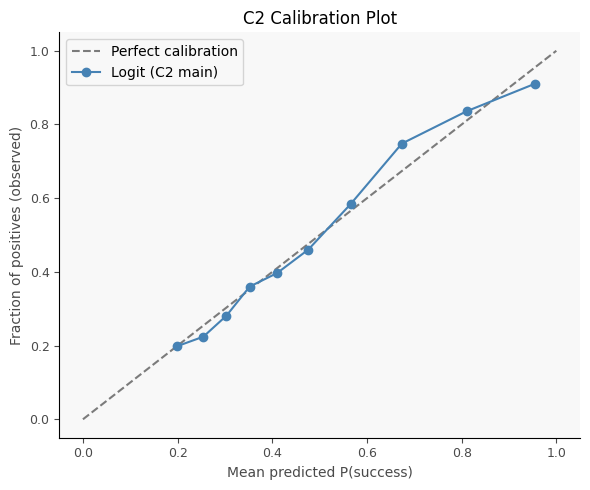

  Calibration plot saved → c2_calibration.png


In [ ]:
# ----------------------------------------------------------------
# 6.8 Model-Based Zone Rankings + Calibration
# ----------------------------------------------------------------
from sklearn.calibration import calibration_curve

# Standardised scenario: median covariates, weekday, clear weather
scenario_template = c2_model_df[c2_features].median().to_dict()
scenario_template['is_weekend']  = 0
scenario_template['bad_weather'] = 0

# Generate per-zone predictions at the standardised scenario
zone_predictions = []
for zone_id, group in c2_df.groupby('PULocationID'):
    if len(group) < 20:
        continue  # exclude rare zones for stable predictions

    scenario = scenario_template.copy()
    # Replace zone-level features with zone-specific median values
    for feat in ['PU_Pop_1E', 'do_zone_quality',
                 'PU_Borough_grouped_Queens']:
        if feat in c2_features:
            scenario[feat] = group[feat].median()

    x_pred = pd.DataFrame([scenario])[c2_features]
    x_pred = sm.add_constant(x_pred, has_constant='add')
    pred_p = float(logit_c2.predict(x_pred).iloc[0])

    zone_predictions.append({
        'PULocationID'   : zone_id,
        'pred_p_success' : pred_p,
        'n_trips'        : len(group),
        'raw_rate'       : group['trip_success'].mean(),
    })

zone_pred_df = (
    pd.DataFrame(zone_predictions)
    .merge(zone_ref, on='PULocationID', how='left')
    .sort_values('pred_p_success', ascending=False)
)

print("\n=== MODEL-BASED ZONE RANKINGS (conditional on covariates) ===")
print("\nTop 10 zones — highest predicted P(success):")
print(zone_pred_df[['PU_Zone', 'PU_Borough', 'n_trips',
                    'pred_p_success', 'raw_rate']]
      .head(10).round(3).to_string(index=False))

print("\nBottom 10 zones — lowest predicted P(success):")
print(zone_pred_df[['PU_Zone', 'PU_Borough', 'n_trips',
                    'pred_p_success', 'raw_rate']]
      .tail(10).round(3).to_string(index=False))

# Compare descriptive vs model-based ranking
corr_ranks = zone_pred_df[['raw_rate', 'pred_p_success']].corr().iloc[0, 1]
print(f"\n  Correlation (raw_rate vs pred_p_success): {corr_ranks:.3f}")
print(f"  → High corr (>0.85) = descriptive rank ≈ model rank;")
print(f"    Lower corr = confounders matter, prefer model-based ranking.")

# ----------------------------------------------------------------
# Calibration plot — predicted vs observed frequencies
# ----------------------------------------------------------------
y_pred_c2 = logit_c2.predict(X_c2)
prob_true, prob_pred = calibration_curve(
    y_c2, y_pred_c2, n_bins=10, strategy='quantile',
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', color='steelblue',
        label='Logit (C2 main)')
ax.set_xlabel('Mean predicted P(success)')
ax.set_ylabel('Fraction of positives (observed)')
ax.set_title('C2 Calibration Plot')
ax.legend()
plt.tight_layout()
plt.savefig('c2_calibration.png', dpi=150)
plt.show()
print("  Calibration plot saved → c2_calibration.png")


### 6.9 Zone-Ranking Visualisation — Where to Start   

A horizontal bar chart of the top-10 and bottom-10 zones by model-based predicted P(success) turns the §6.8 table into an at-a-glance, driver-facing figure. Bars are coloured by borough to expose any spatial clustering of high-earning starts.

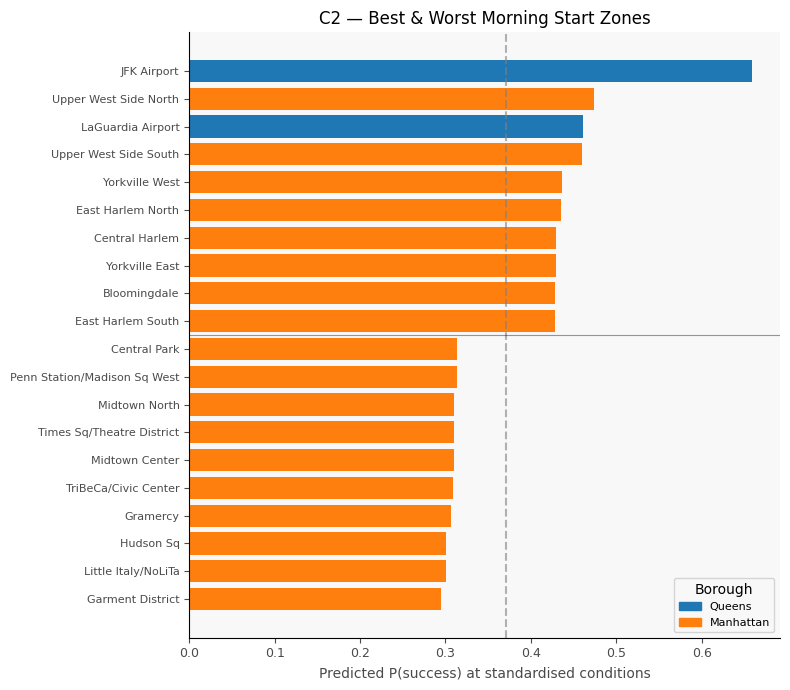

  Zone-ranking bar chart saved → c2_zone_rankings.png


In [ ]:
# ----------------------------------------------------------------
# 6.9 Top/Bottom Zone Bar Chart (model-based P(success))
# ----------------------------------------------------------------
# Visualises zone_pred_df (built in §6.8). Top 10 + bottom 10 by
# predicted success probability, coloured by borough.
# ----------------------------------------------------------------

top10    = zone_pred_df.head(10).copy()
bottom10 = zone_pred_df.tail(10).copy()
plot_df  = pd.concat([top10, bottom10])

# Map boroughs to a stable colour palette
boroughs = plot_df['PU_Borough'].fillna('Unknown').unique()
palette = dict(zip(boroughs, plt.cm.tab10.colors[:len(boroughs)]))
bar_colors = plot_df['PU_Borough'].fillna('Unknown').map(palette)

fig, ax = plt.subplots(figsize=(8, 7))
y_pos = np.arange(len(plot_df))
ax.barh(y_pos, plot_df['pred_p_success'], color=bar_colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['PU_Zone'], fontsize=8)
ax.invert_yaxis()  # highest at top
ax.axvline(plot_df['pred_p_success'].median(), color='gray',
           linestyle='--', alpha=0.6, label='Median (shown zones)')
ax.set_xlabel('Predicted P(success) at standardised conditions')
ax.set_title('C2 — Best & Worst Morning Start Zones')

# Visual separator between top-10 and bottom-10 blocks
ax.axhline(9.5, color='black', linewidth=0.8, alpha=0.4)

# Borough legend
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[b]) for b in boroughs]
ax.legend(handles, boroughs, title='Borough',
          loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('c2_zone_rankings.png', dpi=150)
plt.show()
print("  Zone-ranking bar chart saved → c2_zone_rankings.png")


## PART 7. CHALLENGE 3 — THE TURNOVER TRAP

### Research question
How long does a driver typically wait between pickups, what factors accelerate or delay the next pickup, and when (if ever) should a driver abandon a location?

### Modelling rationale — Cox Proportional Hazards
Inter-pickup waiting time is a **duration outcome with right censoring** (some spells end without an observed next pickup). Standard regression on the duration would be biased; survival analysis is the appropriate framework (Hu et al. 2021).

- **Cox PH** (Lecture 6): semiparametric, no assumed baseline hazard, hazard ratios directly interpretable.
- **Weibull AFT**: fully parametric alternative; the strongest available robustness check.

### 7.1–7.2 Sample Preparation & Kaplan–Meier Curve  


=== C3 MODEL DATA ===
  N             : 62,316
  Event rate    : 83.5%
  Censoring rate: 16.5%
  Median wait   : 4.0 min

>>> Kaplan-Meier survival function...
  Median survival time: 4.0 min


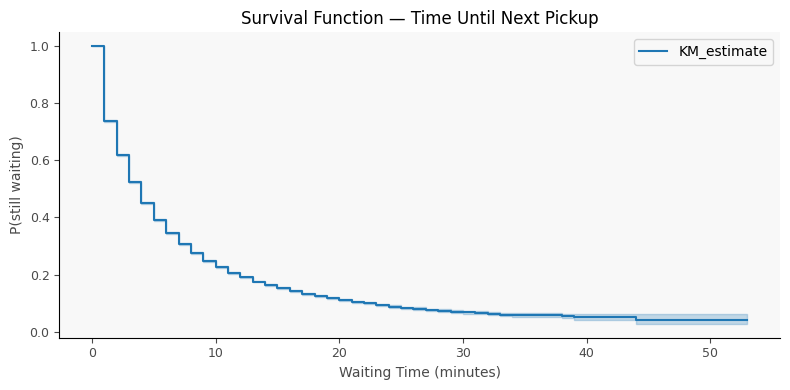

In [ ]:
# ----------------------------------------------------------------
# 7.1 Sample Preparation
# ----------------------------------------------------------------

c3_model_df = c3_df[c3_features + [
    'wait_duration', 'event_observed', 'PULocationID',
]].dropna()

print(f"\n=== C3 MODEL DATA ===")
print(f"  N             : {len(c3_model_df):,}")
print(f"  Event rate    : {c3_model_df['event_observed'].mean()*100:.1f}%")
print(f"  Censoring rate: {(1-c3_model_df['event_observed'].mean())*100:.1f}%")
print(f"  Median wait   : {c3_model_df['wait_duration'].median():.1f} min")

# ----------------------------------------------------------------
# 7.2 Kaplan-Meier Survival Curve
# ----------------------------------------------------------------
print("\n>>> Kaplan-Meier survival function...")
kmf = KaplanMeierFitter()
kmf.fit(c3_model_df['wait_duration'],
        event_observed=c3_model_df['event_observed'])
print(f"  Median survival time: {kmf.median_survival_time_:.1f} min")

plt.figure(figsize=(8, 4))
kmf.plot_survival_function()
plt.title('Survival Function — Time Until Next Pickup')
plt.xlabel('Waiting Time (minutes)')
plt.ylabel('P(still waiting)')
plt.tight_layout()
plt.savefig('c3_kaplan_meier.png', dpi=150)
plt.show()


### 7.3 Cox Proportional Hazards   

In [ ]:
# ----------------------------------------------------------------
# 7.3 Cox Proportional Hazards (with cluster-robust SEs)
# ----------------------------------------------------------------
print("\n>>> Cox PH with cluster-robust SEs at pickup-zone level...")
cph = CoxPHFitter()
cph.fit(
    c3_model_df,
    duration_col='wait_duration',
    event_col='event_observed',
    cluster_col='PULocationID',  # <-- MODIFICATION
    robust=True,
)
cph.print_summary()

hr_df = pd.DataFrame({
    'HR'     : np.exp(cph.params_).round(3),
    'p_value': cph.summary['p'].round(3),
    'sig'    : cph.summary['p'].apply(
        lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    ),
})
print("\n=== HAZARD RATIOS ===")
print(hr_df.sort_values('HR', ascending=False).to_string())



>>> Cox PH with cluster-robust SEs at pickup-zone level...


<lifelines.CoxPHFitter: fitted with 62316 total observations, 10263 right-censored observations>
             duration col = 'wait_duration'
                event col = 'event_observed'
              cluster col = 'PULocationID'
          robust variance = True
      baseline estimation = breslow
   number of observations = 62316
number of events observed = 52053
   partial log-likelihood = -535758.44
         time fit was run = 2026-06-04 16:16:07 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
pickup_hour                        0.03      1.03      0.00            0.02            0.03                1.02                1.03
is_weekend                        -0.04      0.96      0.04           -0.12            0.04                0.88                1.04
is_airport                         0.11      1.11      0.05            0.02            0.20                1.02                1.22
PU_Pop_1E                         -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
bad_weather                        0.03      1.03      0.02           -0.00            0.07                1.00                1.07
temperature_2m                    -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
snowfall                          -0.74      0.48      0.08           -0.90           -0.58                0.40                0.56
PU_Borough_grouped_Queens         -0.54      0.59      0.20           -0.92           -0.15                0.40                0.86
PU_Borough_grouped_Outer Boroughs -1.60      0.20      0.13           -1.85           -1.35                0.16                0.26

                                   cmp to      z      p  -log2(p)
covariate                                                        
pickup_hour                          0.00   7.35 <0.005     42.22
is_weekend                           0.00  -1.01   0.31      1.68
is_airport                           0.00   2.37   0.02      5.80
PU_Pop_1E                            0.00  -0.56   0.58      0.80
bad_weather                          0.00   1.75   0.08      3.63
temperature_2m                       0.00  -0.71   0.48      1.07
snowfall                             0.00  -9.10 <0.005     63.30
PU_Borough_grouped_Queens            0.00  -2.71   0.01      7.20
PU_Borough_grouped_Outer Boroughs    0.00 -12.53 <0.005    117.30
---
Concordance = 0.58
Partial AIC = 1071534.88
log-likelihood ratio test = 2601.02 on 9 df
-log2(p) of ll-ratio test = inf


=== HAZARD RATIOS ===
                                      HR  p_value  sig
covariate                                             
is_airport                         1.114    0.018   **
bad_weather                        1.031    0.081    *
pickup_hour                        1.026    0.000  ***
temperature_2m                     0.999    0.476     
PU_Pop_1E                          0.998    0.575     
is_weekend                         0.959    0.313     
PU_Borough_grouped_Queens          0.586    0.007  ***
snowfall                           0.475    0.000  ***
PU_Borough_grouped_Outer Boroughs  0.203    0.000  ***


### 7.4–7.7 PH Test, Weibull AFT, Sensitivity, Descriptive Zone Rankings   

In [ ]:
# 7.4 PH Assumption Test (Schoenfeld Residuals)
# ----------------------------------------------------------------

print("\n>>> Testing Proportional Hazards assumption...")
ph_test = proportional_hazard_test(cph, c3_model_df, time_transform='rank')
print(ph_test.summary)
print("  p > 0.05 → PH assumption holds ✅")
print("  p < 0.05 → violation → use Weibull AFT")

# ----------------------------------------------------------------
# 7.5 Weibull AFT — Main Model (PH Violated)
# ----------------------------------------------------------------

print("\n>>> Weibull AFT (MAIN MODEL — PH assumption violated)...")
waft = WeibullAFTFitter()
waft.fit(c3_model_df, duration_col='wait_duration', event_col='event_observed')
waft.print_summary()

# ----------------------------------------------------------------
# 7.6 Sensitivity — Exclude Extreme Spells (> 90 min)
# ----------------------------------------------------------------

print("\n=== SENSITIVITY: Exclude spells > 90 min ===")
c3_trimmed = c3_model_df[c3_model_df['wait_duration'] <= 90]
cph_trim   = CoxPHFitter()
cph_trim.fit(c3_trimmed, duration_col='wait_duration',
             event_col='event_observed', robust=True)
hr_trim = pd.DataFrame({
    'HR_main'   : np.exp(cph.params_).round(3),
    'HR_trimmed': np.exp(cph_trim.params_).round(3),
})
print(hr_trim.to_string())
print("→ Similar HRs = results robust to extreme spells")

# ----------------------------------------------------------------
# 7.7 Zone Rankings — Fastest vs Slowest Pickup
# ----------------------------------------------------------------

zone_wait = (
    c3_df.groupby('PULocationID')
    .agg(n_spells=('wait_duration','count'),
         median_wait=('wait_duration','median'),
         event_rate=('event_observed','mean'))
    .reset_index()
    .query('n_spells >= 20')
    .merge(zone_ref, on='PULocationID', how='left')
    .sort_values('median_wait')
)

print("\n=== TOP 10 ZONES — Fastest Pickup ===")
print(zone_wait[['PU_Zone','PU_Borough','n_spells','median_wait','event_rate']]
      .head(10).round(3).to_string(index=False))

print("\n=== TOP 10 ZONES — Slowest Pickup (avoid!) ===")
print(zone_wait[['PU_Zone','PU_Borough','n_spells','median_wait','event_rate']]
      .tail(10).round(3).to_string(index=False))



>>> Testing Proportional Hazards assumption...
                                   test_statistic         p  -log2(p)
PU_Borough_grouped_Outer Boroughs        1.524008  0.217014  2.204141
PU_Borough_grouped_Queens                1.936268  0.164074  2.607579
PU_Pop_1E                                1.037132  0.308490  1.696707
bad_weather                              0.288482  0.591195  0.758294
is_airport                               0.006251  0.936981  0.093908
is_weekend                               1.303187  0.253632  1.979192
pickup_hour                              0.438204  0.507990  0.977127
snowfall                                 0.481134  0.487909  1.035315
temperature_2m                           0.744171  0.388328  1.364652
  p > 0.05 → PH assumption holds ✅
  p < 0.05 → violation → use Weibull AFT

>>> Weibull AFT (MAIN MODEL — PH assumption violated)...


<lifelines.WeibullAFTFitter: fitted with 62316 total observations, 10263 right-censored observations>
             duration col = 'wait_duration'
                event col = 'event_observed'
   number of observations = 62316
number of events observed = 52053
           log-likelihood = -150167.76
         time fit was run = 2026-06-04 16:17:18 UTC

---
                                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                          
lambda_ PULocationID                      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
        PU_Borough_grouped_Outer Boroughs  1.65      5.18      0.11            1.42            1.87                4.14                6.49
        PU_Borough_grouped_Queens          0.55      1.73      0.02            0.51            0.59                1.66                1.80
        PU_Pop_1E                          0.00      1.00      0.00            0.00            0.00                1.00                1.00
        bad_weather                       -0.04      0.96      0.02           -0.07           -0.00                0.93                1.00
        is_airport                        -0.12      0.89      0.03           -0.18           -0.06                0.84                0.94
        is_weekend                         0.05      1.05      0.01            0.03            0.07                1.03                1.07
        pickup_hour                       -0.03      0.97      0.00           -0.03           -0.03                0.97                0.97
        snowfall                           0.83      2.28      0.08            0.67            0.98                1.96                2.66
        temperature_2m                     0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        Intercept                          2.65     14.11      0.02            2.61            2.69               13.57               14.66
rho_    Intercept                         -0.02      0.98      0.00           -0.03           -0.01                0.97                0.99

                                           cmp to      z      p  -log2(p)
param   covariate                                                        
lambda_ PULocationID                         0.00 -42.70 <0.005       inf
        PU_Borough_grouped_Outer Boroughs    0.00  14.31 <0.005    151.90
        PU_Borough_grouped_Queens            0.00  27.22 <0.005    539.44
        PU_Pop_1E                            0.00  15.11 <0.005    168.86
        bad_weather                          0.00  -2.03   0.04      4.55
        is_airport                           0.00  -4.24 <0.005     15.44
        is_weekend                           0.00   4.60 <0.005     17.87
        pickup_hour                          0.00 -36.99 <0.005    992.53
        snowfall                             0.00  10.53 <0.005     83.69
        temperature_2m                       0.00   1.10   0.27      1.89
        Intercept                            0.00 133.48 <0.005       inf
rho_    Intercept                            0.00  -5.76 <0.005     26.84
---
Concordance = 0.60
AIC = 300359.53
log-likelihood ratio test = 4966.71 on 10 df
-log2(p) of ll-ratio test = inf


=== SENSITIVITY: Exclude spells > 90 min ===
                                   HR_main  HR_trimmed
covariate                                             
PULocationID                           NaN       1.003
PU_Borough_grouped_Outer Boroughs    0.203       0.225
PU_Borough_grouped_Queens            0.586       0.603
PU_Pop_1E                            0.998       0.997
bad_weather                          1.031       1.032
is_airport                           1.114       1.114
is_weekend                           0.959       0.958
pickup_hour                          1.026       1.026
snowfall                             0.475       0.473
temperature_2m                       0.999       0.999
→ Similar HRs = results robust to extreme spells

=== TOP 10 ZONES — Fastest Pickup ===
                     PU_Zone PU_Borough  n_spells  median_wait  event_rate
            Garment District  Manhattan       883          2.0       0.921
       Upper East Side South  Manhattan      3470       

### 7.8 What makes drivers wait longer?   

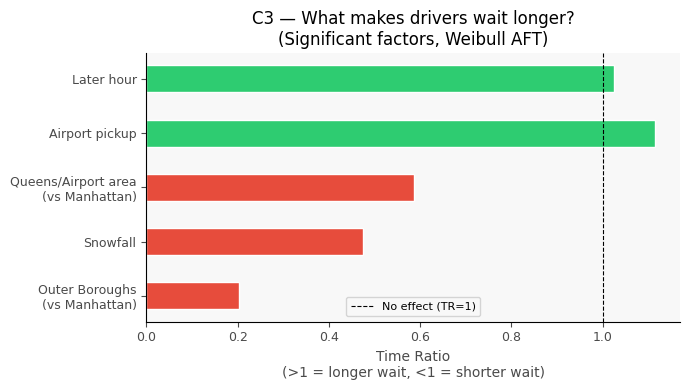

In [ ]:
sig_tr = {
    'Outer Boroughs\n(vs Manhattan)': 0.203,
    'Snowfall'                       : 0.474,
    'Queens/Airport area\n(vs Manhattan)': 0.586,
    'Airport pickup'                 : 1.114,
    'Later hour'                     : 1.026,
}

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71' if v > 1 else '#e74c3c'
          for v in sig_tr.values()]

ax.barh(list(sig_tr.keys()), list(sig_tr.values()),
        color=colors, edgecolor='white', height=0.5)
ax.axvline(1.0, color='black', linewidth=0.8,
           linestyle='--', label='No effect (TR=1)')
ax.set_xlabel('Time Ratio\n(>1 = longer wait, <1 = shorter wait)')
ax.set_title('C3 — What makes drivers wait longer?\n'
             '(Significant factors, Weibull AFT)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('c3_time_ratios.png', dpi=150)
plt.show()

### 7.8b Threshold-Based Driver Advice — "When to Give Up"   

The advice that helps drivers *"know when to wait, and when waiting is likely futile."
-> The hazard ratios answer *what* speeds up a pickup, but not *when to abandon a spot*. We close that gap with **conditional survival probabilities**.

#### Method
From the fitted Cox model we obtain each driver's survival curve $S(t)$. The probability of waiting at least $s$ **more** minutes, given one has *already* waited $t$ minutes, is:

$$P(T > t + s \mid T > t) = \frac{S(t + s)}{S(t)}$$

We evaluate this at representative "already-waited" thresholds (5, 10, 15, 20 min) for a fast-pickup vs slow-pickup zone profile, producing a simple decision table: *if the conditional probability of a further long wait is high, the rational action is to relocate.*


=== 'WHEN TO GIVE UP' DECISION TABLE ===
  Fast-pickup zone : Randalls Island
  Slow-pickup zone : Erasmus
  Median wait (overall): 4.0 min

 already_waited_min  P(>=10 more | fast zone)  P(>=10 more | slow zone)
                  5                     0.295                     0.872
                 10                     0.392                     0.900
                 15                     0.448                     0.914
                 20                     0.511                     0.927

  Rule of thumb (futility threshold = 50%):
  → In SLOW zones, if the chance of 10+ more minutes of
    waiting exceeds 50%, relocating is advised.


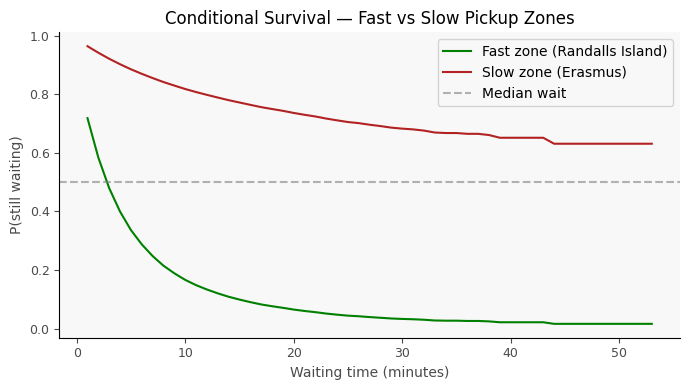

  Conditional survival plot saved → c3_conditional_survival.png


In [ ]:
# ----------------------------------------------------------------
# 7.8b Conditional Survival → 'When to Give Up' Decision Table
# ----------------------------------------------------------------
# Builds driver-facing advice from the fitted Cox model (`cph`).
# Compares a representative FAST-pickup zone profile against a
# SLOW-pickup one, then tabulates P(wait >= s more min | already t).
# ----------------------------------------------------------------

def conditional_wait_probability(
    survival_fn: pd.Series,
    already_waited: float,
    extra: float,
) -> float:
    """P(T > already_waited + extra | T > already_waited).

    Uses S(t+s)/S(t) with nearest-time lookup on the step function.

    Parameters
    ----------
    survival_fn : pd.Series
        Survival curve indexed by time (from cph.predict_survival_function).
    already_waited : float
        Minutes already waited (conditioning time t).
    extra : float
        Additional minutes of interest (s).
    """
    times = survival_fn.index.values
    s_t = survival_fn.values[np.searchsorted(times, already_waited,
                                             side='right') - 1]
    idx_ts = np.searchsorted(times, already_waited + extra,
                             side='right') - 1
    s_ts = survival_fn.values[max(idx_ts, 0)]
    if s_t <= 0:
        return np.nan
    return float(s_ts / s_t)


# ---- Build representative fast vs slow zone profiles --------------
# Rank zones by mean partial hazard (computed in §8 if available, else
# recompute locally for self-containment).
c3_local = c3_model_df.copy()
c3_local['ph'] = cph.predict_partial_hazard(c3_model_df)
zone_speed = c3_local.groupby('PULocationID')['ph'].mean().sort_values()

slow_zone_id = zone_speed.index[0]    # lowest hazard => slowest pickup
fast_zone_id = zone_speed.index[-1]   # highest hazard => fastest pickup

# Representative covariate row per zone (median within zone)
def zone_profile(zone_id):
    """Median covariate vector for a given pickup zone."""
    rows = c3_model_df[c3_model_df['PULocationID'] == zone_id]
    return rows[c3_features].median().to_frame().T

fast_profile = zone_profile(fast_zone_id)
slow_profile = zone_profile(slow_zone_id)

# Survival curves for the two profiles
sf_fast = cph.predict_survival_function(fast_profile).iloc[:, 0]
sf_slow = cph.predict_survival_function(slow_profile).iloc[:, 0]

# ---- Decision table ------------------------------------------------
already_grid = [5, 10, 15, 20]
extra = 10  # probability of >=10 MORE minutes of waiting

advice_rows = []
for t in already_grid:
    p_fast = conditional_wait_probability(sf_fast, t, extra)
    p_slow = conditional_wait_probability(sf_slow, t, extra)
    advice_rows.append({
        'already_waited_min': t,
        f'P(>={extra} more | fast zone)': p_fast,
        f'P(>={extra} more | slow zone)': p_slow,
    })
advice_table = pd.DataFrame(advice_rows)

# Look up readable labels
fast_label = zone_ref.loc[zone_ref['PULocationID'] == fast_zone_id,
                          'PU_Zone'].squeeze()
slow_label = zone_ref.loc[zone_ref['PULocationID'] == slow_zone_id,
                          'PU_Zone'].squeeze()

print("\n=== 'WHEN TO GIVE UP' DECISION TABLE ===")
print(f"  Fast-pickup zone : {fast_label}")
print(f"  Slow-pickup zone : {slow_label}")
print(f"  Median wait (overall): "
      f"{kmf.median_survival_time_:.1f} min\n")
print(advice_table.round(3).to_string(index=False))

# Simple rule-of-thumb derived from the table
futility_threshold = 0.50
print(f"\n  Rule of thumb (futility threshold = {futility_threshold:.0%}):")
print(f"  → In SLOW zones, if the chance of {extra}+ more minutes of")
print(f"    waiting exceeds {futility_threshold:.0%}, relocating is advised.")

# ---- Visual: conditional survival curves --------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sf_fast.index, sf_fast.values, label=f'Fast zone ({fast_label})',
        color='green')
ax.plot(sf_slow.index, sf_slow.values, label=f'Slow zone ({slow_label})',
        color='firebrick')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6,
           label='Median wait')
ax.set_xlabel('Waiting time (minutes)')
ax.set_ylabel('P(still waiting)')
ax.set_title('Conditional Survival — Fast vs Slow Pickup Zones')
ax.legend()
plt.tight_layout()
plt.savefig('c3_conditional_survival.png', dpi=150)
plt.show()
print("  Conditional survival plot saved → c3_conditional_survival.png")


### 7.9 C3 Results Summary

In [ ]:
# ----------------------------------------------------------------
# 7.9 C3 Results Summary
# ----------------------------------------------------------------

print("\n" + "="*50)
print("C3 RESULTS SUMMARY")
print("="*50)
print(f"  Primary model : Weibull AFT (Cox PH assumption violated)")
print(f"  Robustness    : Cox PH")
print(f"  N={len(c3_model_df):,} | Event rate={c3_model_df['event_observed'].mean()*100:.1f}%")
print(f"  Median wait   : {c3_model_df['wait_duration'].median():.1f} min")
print(f"  Harrell C-index (Cox): {cph.concordance_index_:.4f}")

# Weibull AFT significant results (main model)
print("\n  Weibull AFT — significant predictors (p<0.05):")
waft_summary = waft.summary.loc['lambda_'].copy()
waft_sig = waft_summary[waft_summary['p'] < 0.05][['coef','exp(coef)','p']].copy()
waft_sig.columns = ['coef (log scale)', 'Time Ratio', 'p_value']
waft_sig['sig'] = waft_sig['p_value'].apply(
    lambda p: '***' if p<0.01 else ('**' if p<0.05 else '*')
)
waft_sig['interpretation'] = waft_sig['Time Ratio'].apply(
    lambda tr: f"wait {abs(1-tr)*100:.1f}% {'longer' if tr>1 else 'shorter'}"
)
print(waft_sig.round(3).to_string())

# Cox PH as robustness
print("\n  Cox PH robustness — significant HRs (p<0.05):")
print(hr_df[hr_df['p_value']<0.05].sort_values('HR', ascending=False).to_string())



C3 RESULTS SUMMARY
  Primary model : Weibull AFT (Cox PH assumption violated)
  Robustness    : Cox PH
  N=62,316 | Event rate=83.5%
  Median wait   : 4.0 min
  Harrell C-index (Cox): 0.5757

  Weibull AFT — significant predictors (p<0.05):
                                   coef (log scale)  Time Ratio  p_value  sig       interpretation
covariate                                                                                         
PULocationID                                 -0.003       0.997    0.000  ***    wait 0.3% shorter
PU_Borough_grouped_Outer Boroughs             1.645       5.182    0.000  ***   wait 418.2% longer
PU_Borough_grouped_Queens                     0.548       1.730    0.000  ***    wait 73.0% longer
PU_Pop_1E                                     0.003       1.003    0.000  ***     wait 0.3% longer
bad_weather                                  -0.036       0.964    0.043   **    wait 3.6% shorter
is_airport                                   -0.120       0.887  

## PART 8. CROSS-CHALLENGE SYNTHESIS  

This section ties the three challenges together — directly supporting the **Overall Report (15%)** criterion on *structure and argumentation* and feeding the report's Discussion/Conclusion.

**Goal**: identify zones/times that are *consistently* favourable (or unfavourable) across all three outcomes, expose trade-offs, and produce a single integrated recommendation table that the report can lift directly into its conclusion.

We rank each pickup zone on three standardised dimensions:
- **Tipping** — mean predicted tip percentage (C1)
- **Earning efficiency** — predicted P(success) at standardised conditions (C2)
- **Pickup speed** — mean predicted partial hazard, i.e. how quickly a next pickup arrives (C3); higher = shorter wait

Dimensions are z-scored so they are comparable, then averaged into a composite "zone attractiveness" score. A high composite means the zone is good on multiple fronts; large *disagreement* across dimensions flags a trade-off worth discussing.

In [ ]:
# ----------------------------------------------------------------
# 8.1 Cross-Challenge Zone Synthesis
# ----------------------------------------------------------------
# Combines per-zone signals from C1 (tipping), C2 (earning success),
# and C3 (pickup speed) into one comparable table. Each signal is
# z-scored so the composite is not dominated by scale differences.
#
# NOTE: relies on objects created earlier:
#   - logit_s1, gamma_s2  (C1)
#   - zone_pred_df        (C2)
#   - cph                 (C3)
#   - zone_ref            (PULocationID -> PU_Zone / PU_Borough lookup)
# ----------------------------------------------------------------

def zscore(s: pd.Series) -> pd.Series:
    """Standardise a series to mean 0, sd 1 (NaN-safe)."""
    return (s - s.mean()) / s.std(ddof=0)


# ---- C1 signal: mean predicted tip_pct per pickup zone -----------
# Joint hurdle prediction: P(tip>0) * E[tip_pct | tip>0]
c1_zone_df = c1_s1.copy()
X1_all = sm.add_constant(c1_zone_df[c1_features])
c1_zone_df['pred_tip_pct'] = (
    logit_s1.predict(X1_all) * np.exp(X1_all @ gamma_s2.params)
)
c1_signal = (
    c1_zone_df.groupby('PULocationID')['pred_tip_pct']
    .mean().rename('c1_tip')
)

# ---- C2 signal: model-based P(success) per zone (from §6.8) -------
c2_signal = (
    zone_pred_df.set_index('PULocationID')['pred_p_success']
    .rename('c2_success')
)

# ---- C3 signal: mean predicted partial hazard per zone ------------
# Higher partial hazard => next pickup arrives sooner => shorter wait.
c3_zone_df = c3_model_df.copy()
c3_zone_df['partial_hazard'] = cph.predict_partial_hazard(c3_model_df)
c3_signal = (
    c3_zone_df.groupby('PULocationID')['partial_hazard']
    .mean().rename('c3_speed')
)

# ---- Merge the three signals --------------------------------------
synthesis = (
    pd.concat([c1_signal, c2_signal, c3_signal], axis=1)
    .dropna()  # keep zones present in all three challenges
)

# Standardise each dimension, then build composite score
synthesis['z_tip']     = zscore(synthesis['c1_tip'])
synthesis['z_success'] = zscore(synthesis['c2_success'])
synthesis['z_speed']   = zscore(synthesis['c3_speed'])
synthesis['composite'] = synthesis[['z_tip', 'z_success', 'z_speed']].mean(axis=1)

# Trade-off flag: large spread across the three z-scores
synthesis['tradeoff_spread'] = (
    synthesis[['z_tip', 'z_success', 'z_speed']].max(axis=1)
    - synthesis[['z_tip', 'z_success', 'z_speed']].min(axis=1)
)

# Attach human-readable zone labels
synthesis = (
    synthesis.reset_index()
    .merge(zone_ref, on='PULocationID', how='left')
    .sort_values('composite', ascending=False)
)

display_cols = ['PU_Zone', 'PU_Borough',
                'z_tip', 'z_success', 'z_speed',
                'composite', 'tradeoff_spread']

print("\n=== CROSS-CHALLENGE ZONE SYNTHESIS ===")
print("\nTop 10 all-round zones (high composite):")
print(synthesis[display_cols].head(10).round(2).to_string(index=False))

print("\nBottom 10 zones (low composite):")
print(synthesis[display_cols].tail(10).round(2).to_string(index=False))

print("\nLargest trade-off zones (good on one dimension, poor on another):")
print(synthesis.sort_values('tradeoff_spread', ascending=False)[display_cols]
      .head(8).round(2).to_string(index=False))



=== CROSS-CHALLENGE ZONE SYNTHESIS ===

Top 10 all-round zones (high composite):
              PU_Zone PU_Borough  z_tip  z_success  z_speed  composite  tradeoff_spread
Upper West Side North  Manhattan   0.80       1.59    -0.78       0.53             2.37
Upper West Side South  Manhattan   0.83       1.38    -0.66       0.52             2.04
       Yorkville West  Manhattan   1.02       1.00    -0.50       0.51             1.52
  Lincoln Square West  Manhattan   1.10       0.63    -0.26       0.49             1.36
    East Harlem South  Manhattan   0.66       0.87    -0.13       0.47             1.00
     Manhattan Valley  Manhattan   0.73       0.58     0.08       0.46             0.65
Upper East Side South  Manhattan   0.98       0.09     0.31       0.46             0.89
      Lenox Hill West  Manhattan   1.06       0.68    -0.38       0.45             1.43
  Lincoln Square East  Manhattan   0.66       0.42     0.22       0.43             0.44
    East Harlem North  Manhattan   0.3

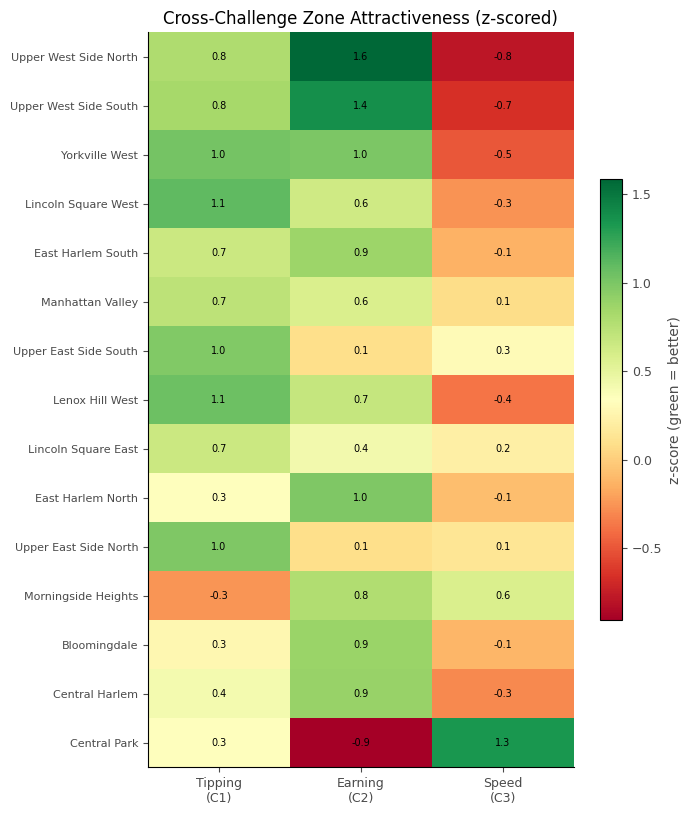

  Synthesis heatmap saved → cross_challenge_heatmap.png


In [ ]:
# ----------------------------------------------------------------
# 8.2 Synthesis Visualisation — Heatmap of Top Zones
# ----------------------------------------------------------------
# A compact heatmap of z-scored signals for the top-15 composite
# zones makes cross-challenge patterns and trade-offs visible at a
# glance — ideal as the single integrating figure in the report.

top_n = 15
heat_data = (
    synthesis.head(top_n)
    .set_index('PU_Zone')[['z_tip', 'z_success', 'z_speed']]
)

fig, ax = plt.subplots(figsize=(7, 0.45 * top_n + 1.5))
im = ax.imshow(heat_data.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(3))
ax.set_xticklabels(['Tipping\n(C1)', 'Earning\n(C2)', 'Speed\n(C3)'])
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=8)
ax.set_title('Cross-Challenge Zone Attractiveness (z-scored)')

# Annotate each cell with its value
for r in range(heat_data.shape[0]):
    for c in range(heat_data.shape[1]):
        ax.text(c, r, f'{heat_data.values[r, c]:.1f}',
                ha='center', va='center', fontsize=7,
                color='black')

fig.colorbar(im, ax=ax, shrink=0.6, label='z-score (green = better)')
plt.tight_layout()
plt.savefig('cross_challenge_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Synthesis heatmap saved → cross_challenge_heatmap.png")
